# Libraries and functions

In [4]:
from pathlib import Path
import json
import itertools
import math

import torch
import numpy as np
import matplotlib.pyplot as plt


def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product_like_driver(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _get_times_and_blocks(payload):
    if "times" in payload and "by_time" in payload:
        return payload["times"], payload["by_time"]

    if "epochs" in payload and "by_epoch" in payload:
        return payload["epochs"], payload["by_epoch"]

    raise ValueError("Unknown SVD payload format.")


def _build_combos_with_coupled_grid_like_driver(cfg):
    """
    Reproduce the same order used in experiment_age_phase_diagram.py:

        base_combos = cartesian_product(grid)
        for base in base_combos:
            for coupled in coupled_grid:
                merged = base + coupled

    In the usual case, base_combos has length 1, so combo_index == q.
    """
    grid = cfg.get("grid", {})
    coupled_grid = cfg.get("coupled_grid", None)

    if not grid:
        raise ValueError("Config must contain a non-empty 'grid' dictionary.")

    if not isinstance(coupled_grid, list) or len(coupled_grid) == 0:
        raise ValueError(
            "list_instead_of_grid=True requires a non-empty 'coupled_grid' list."
        )

    for q, point in enumerate(coupled_grid):
        if not isinstance(point, dict):
            raise ValueError(f"coupled_grid[{q}] must be a dictionary.")
        if "lr" not in point or "inv_sigma_w" not in point:
            raise ValueError(
                f"coupled_grid[{q}] must contain both 'lr' and 'inv_sigma_w'."
            )

    coupled_keys = set()
    for point in coupled_grid:
        coupled_keys.update(point.keys())

    overlap = set(grid.keys()).intersection(coupled_keys)
    if overlap:
        raise ValueError(
            "A parameter cannot appear both in grid and coupled_grid. "
            f"Overlapping keys: {sorted(overlap)}"
        )

    base_combos = _cartesian_product_like_driver(grid)

    combos = []
    records = []

    for base_index, base_combo in enumerate(base_combos):
        for q, coupled_point in enumerate(coupled_grid):
            combo = dict(base_combo)
            combo.update(dict(coupled_point))

            combo_index = len(combos)
            combos.append(combo)

            records.append(
                {
                    "q": q,
                    "base_index": base_index,
                    "combo_index": combo_index,
                    "combo": combo,
                }
            )

    return combos, records


def _find_first_available_seed_svd_file(combo_dir, svd_filename):
    """
    Return only one SVD file.

    If the combo folder contains several seed folders, use the first seed folder
    that contains svd_filename. This avoids concatenating histograms across seeds.

    Expected structure:
        combo_0000_hash/
            seed_0001_hash/svd_diagnostics.pt
            seed_0002_hash/svd_diagnostics.pt
            ...

    Returns
    -------
    svd_path, seed_dir
    """
    combo_dir = Path(combo_dir)

    seed_dirs = sorted(
        p for p in combo_dir.glob("seed_*")
        if p.is_dir()
    )

    if len(seed_dirs) > 0:
        for seed_dir in seed_dirs:
            candidates = sorted(seed_dir.rglob(svd_filename))
            if len(candidates) > 0:
                return candidates[0], seed_dir

        return None, None

    # Fallback for old layouts without seed_* folders.
    candidates = sorted(combo_dir.rglob(svd_filename))
    if len(candidates) > 0:
        return candidates[0], candidates[0].parent

    return None, None


def _load_single_svd_file_into_entry(
    *,
    entry,
    svd_path,
    value_keys,
):
    payload = torch.load(svd_path, map_location="cpu")
    times, blocks = _get_times_and_blocks(payload)

    for t in times:
        t_int = int(t)
        t_key = str(t_int)
        if t_key not in blocks:
            t_key = str(t)

        block = blocks[t_key]
        layer_order = block.get("layer_order", list(block["layers"].keys()))

        if entry["layer_order"] is None:
            entry["layer_order"] = list(layer_order)

        if t_int not in entry["by_time"]:
            entry["by_time"][t_int] = {}

        for layer_name in layer_order:
            if layer_name not in entry["by_time"][t_int]:
                entry["by_time"][t_int][layer_name] = {
                    key: [] for key in value_keys
                }

            layer_payload = block["layers"][layer_name]

            for key in value_keys:
                if key in layer_payload:
                    vals = np.asarray(layer_payload[key], dtype=np.float64)
                    entry["by_time"][t_int][layer_name][key].append(vals)

    # Convert list-of-arrays to one array.
    for t in entry["by_time"]:
        for layer_name in entry["by_time"][t]:
            for key in value_keys:
                arrays = entry["by_time"][t][layer_name][key]
                if len(arrays) > 0:
                    entry["by_time"][t][layer_name][key] = np.concatenate(arrays)
                else:
                    entry["by_time"][t][layer_name][key] = np.array([], dtype=np.float64)


def load_all_svd_once(
    results_dir,
    config_path,
    *,
    svd_filename="svd_diagnostics.pt",
    value_keys=("gram_eigenvalues", "singular_values"),
    list_instead_of_grid=False,
):
    """
    Load SVD diagnostics once.

    Old mode
    --------
    list_instead_of_grid=False

    Config has:
        grid["lr"]
        grid["inv_sigma_w"]

    Store key:
        store["data"][(a,b)]

    where:
        a = lr index
        b = inv_sigma_w index

    New mode
    --------
    list_instead_of_grid=True

    Config has:
        grid = fixed hyperparameters
        coupled_grid = [
            {"lr": ..., "inv_sigma_w": ...},
            {"lr": ..., "inv_sigma_w": ...},
            ...
        ]

    Store key:
        store["data"][q]

    where:
        q = index inside coupled_grid.

    Seed behavior
    -------------
    If more than one seed exists inside a combo folder, this function loads only
    the first seed folder available. It does not concatenate across seeds.
    """
    results_dir = Path(results_dir)
    config_path = Path(config_path)

    cfg = json.loads(config_path.read_text())
    grid = cfg["grid"]

    store = {
        "results_dir": results_dir,
        "config_path": config_path,
        "list_instead_of_grid": bool(list_instead_of_grid),
        "data": {},
        "combos": None,
        "lr_values": None,
        "inv_sigma_w_values": None,
        "coupled_grid": cfg.get("coupled_grid", None),
        "key_meaning": None,
    }

    # ============================================================
    # MODE 1: old Cartesian grid
    # ============================================================
    if not list_instead_of_grid:
        if "lr" not in grid or "inv_sigma_w" not in grid:
            raise ValueError(
                "list_instead_of_grid=False requires grid['lr'] and grid['inv_sigma_w']. "
                "For coupled_grid configs, use list_instead_of_grid=True."
            )

        lr_values = _as_list(grid["lr"])
        inv_sigma_w_values = _as_list(grid["inv_sigma_w"])
        combos = _cartesian_product_like_driver(grid)

        store["combos"] = combos
        store["lr_values"] = lr_values
        store["inv_sigma_w_values"] = inv_sigma_w_values
        store["key_meaning"] = "(a,b) = (lr_index, inv_sigma_w_index)"

        for a, lr in enumerate(lr_values):
            for b, inv_sigma_w in enumerate(inv_sigma_w_values):
                matching_combo_indices = []

                for combo_index, combo in enumerate(combos):
                    if (
                        np.isclose(float(combo.get("lr")), float(lr), rtol=1e-14, atol=0.0)
                        and np.isclose(
                            float(combo.get("inv_sigma_w")),
                            float(inv_sigma_w),
                            rtol=1e-14,
                            atol=0.0,
                        )
                    ):
                        matching_combo_indices.append(combo_index)

                if len(matching_combo_indices) == 0:
                    continue

                if len(matching_combo_indices) > 1:
                    print(
                        f"[WARN] More than one combo matches (a,b)=({a},{b}). "
                        f"I will use the first one: {matching_combo_indices[0]}"
                    )

                combo_index = matching_combo_indices[0]
                combo = combos[combo_index]

                combo_dirs = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))
                if len(combo_dirs) == 0:
                    print(
                        f"[WARN] Missing folder for combo_index={combo_index}, "
                        f"(a,b)=({a},{b})"
                    )
                    continue

                combo_dir = combo_dirs[0]
                svd_path, seed_dir = _find_first_available_seed_svd_file(
                    combo_dir,
                    svd_filename,
                )

                if svd_path is None:
                    print(
                        f"[WARN] No {svd_filename} found for combo_index={combo_index}, "
                        f"(a,b)=({a},{b})"
                    )
                    continue

                entry = {
                    "a": a,
                    "b": b,
                    "q": None,
                    "combo_index": combo_index,
                    "combo": combo,
                    "combo_dir": combo_dir,
                    "seed_dir_used": seed_dir,
                    "svd_file_used": svd_path,
                    "svd_files": [svd_path],
                    "by_time": {},
                    "layer_order": None,
                }

                _load_single_svd_file_into_entry(
                    entry=entry,
                    svd_path=svd_path,
                    value_keys=value_keys,
                )

                store["data"][(a, b)] = entry

        print(f"[DONE] loaded {len(store['data'])} available (a,b) combos into memory.")
        print("[INFO] mode = grid")
        print("[INFO] key meaning:", store["key_meaning"])
        return store

    # ============================================================
    # MODE 2: coupled_grid list
    # ============================================================
    combos, records = _build_combos_with_coupled_grid_like_driver(cfg)

    store["combos"] = combos
    store["lr_values"] = [point["lr"] for point in cfg["coupled_grid"]]
    store["inv_sigma_w_values"] = [point["inv_sigma_w"] for point in cfg["coupled_grid"]]
    store["key_meaning"] = "q = index inside coupled_grid"

    for record in records:
        q = int(record["q"])
        base_index = int(record["base_index"])
        combo_index = int(record["combo_index"])
        combo = record["combo"]

        # If the base grid has more than one combo, the same q appears several times.
        # In that case we use a tuple key to avoid collisions.
        # In your usual case base_index=0, so the key is simply q.
        if len(_cartesian_product_like_driver(grid)) == 1:
            data_key = q
        else:
            data_key = (q, base_index)

        combo_dirs = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))
        if len(combo_dirs) == 0:
            print(
                f"[WARN] Missing folder for combo_index={combo_index}, "
                f"q={q}, base_index={base_index}, combo={combo}"
            )
            continue

        combo_dir = combo_dirs[0]
        svd_path, seed_dir = _find_first_available_seed_svd_file(
            combo_dir,
            svd_filename,
        )

        if svd_path is None:
            print(
                f"[WARN] No {svd_filename} found for combo_index={combo_index}, "
                f"q={q}, base_index={base_index}, combo={combo}"
            )
            continue

        entry = {
            "a": None,
            "b": None,
            "q": q,
            "base_index": base_index,
            "combo_index": combo_index,
            "combo": combo,
            "combo_dir": combo_dir,
            "seed_dir_used": seed_dir,
            "svd_file_used": svd_path,
            "svd_files": [svd_path],
            "by_time": {},
            "layer_order": None,
        }

        _load_single_svd_file_into_entry(
            entry=entry,
            svd_path=svd_path,
            value_keys=value_keys,
        )

        store["data"][data_key] = entry

    print(f"[DONE] loaded {len(store['data'])} available q combos into memory.")
    print("[INFO] mode = list/coupled_grid")
    print("[INFO] key meaning:", store["key_meaning"])
    print("[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...")
    return store

In [1]:
def _normalise_layer_name_for_overlap(layer_name):
    layer_name = str(layer_name)
    if layer_name.endswith(".weight"):
        layer_name = layer_name[: -len(".weight")]
    return layer_name


def _get_overlap_A_text_for_panel(
    q_a,
    *,
    lr,
    inv_sigma_w,
    epoch,
    layer_name,
    value_field="A_mean",
    std_field="A_std",
    rtol=1e-12,
    atol=1e-15,
    fmt=".3f",
):
    if q_a is None:
        return None

    required = {"lr", "inv_sigma_w", "epoch", "layer_name", value_field, std_field}
    available = set(q_a.dtype.names or [])
    missing = required - available
    if missing:
        raise ValueError(
            f"q_a is missing required fields: {sorted(missing)}. "
            f"Available fields are: {sorted(available)}"
        )

    target_layer = _normalise_layer_name_for_overlap(layer_name)
    q_layers = np.array(
        [_normalise_layer_name_for_overlap(x) for x in q_a["layer_name"]],
        dtype=object,
    )

    mask = (
        np.isclose(q_a["lr"].astype(float), float(lr), rtol=rtol, atol=atol)
        & np.isclose(q_a["inv_sigma_w"].astype(float), float(inv_sigma_w), rtol=rtol, atol=atol)
        & (q_a["epoch"].astype(int) == int(epoch))
        & (q_layers == target_layer)
    )

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None

    row = q_a[idx[0]]

    val = float(row[value_field])
    std = float(row[std_field])

    if not np.isfinite(val):
        return None

    if np.isfinite(std):
        return rf"$q = {val:{fmt}} \pm {std:{fmt}}$"
    
    return rf"$q = {val:{fmt}}$"


def plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    *,
    a=None,
    b=None,
    list_instead_of_grid=False,
    list_number=None,
    layers=None,
    validation_times=None,
    value_key="gram_eigenvalues",
    bins=40,
    log_x=True,
    density=True,
    shared_bins="layer",
    figsize_per_panel=(3.6, 2.7),
    q_a=None,
    overlap_value_field="A_mean",
    overlap_std_field="A_std",
    overlap_fmt=".3f",
    overlap_rtol=1e-12,
    overlap_atol=1e-15,
    mark_top_k=5,
    mark_top_k_color="red",
    mark_top_k_size=45,
):
    """
    SAME FUNCTION NAME, two possible modes.

    OLD GRID MODE
    -------------
    list_instead_of_grid=False

    Use:
        plot_svd_histograms_layers_by_time_from_store(
            svd_store,
            a=4,
            b=4,
            layers=["layers.0"],
            ...
        )

    The function uses:
        svd_store["data"][(a,b)]


    NEW COUPLED-GRID / LIST MODE
    ----------------------------
    list_instead_of_grid=True

    Use:
        plot_svd_histograms_layers_by_time_from_store(
            svd_store,
            list_instead_of_grid=True,
            list_number=4,
            layers=["layers.0"],
            ...
        )

    The function uses:
        svd_store["data"][list_number]

    So list_number=4 means:
        cfg["coupled_grid"][4]
    """

    # ------------------------------------------------------------
    # Select the correct key without changing the function name.
    # ------------------------------------------------------------
    if list_instead_of_grid:
        if list_number is None:
            raise ValueError(
                "You set list_instead_of_grid=True, so you must pass list_number=0,1,2,..."
            )

        key = int(list_number)

        # Standard case from the loader I gave you:
        # store["data"][q]
        if key not in svd_store["data"]:
            # Fallback if the loader used (q, base_index), typically (q,0).
            fallback_key = (key, 0)
            if fallback_key in svd_store["data"]:
                key = fallback_key
            else:
                available = list(svd_store["data"].keys())
                raise KeyError(
                    f"No loaded data for list_number={list_number}. "
                    f"Available keys are: {available}"
                )

        mode_label = f"list_number={list_number}"

    else:
        if a is None or b is None:
            raise ValueError(
                "You set list_instead_of_grid=False, so you must pass both a=... and b=..."
            )

        key = (int(a), int(b))

        if key not in svd_store["data"]:
            available = list(svd_store["data"].keys())
            raise KeyError(
                f"No loaded data for combo (a,b)=({a},{b}). "
                f"Available keys are: {available}"
            )

        mode_label = f"combo ({int(a)},{int(b)})"

    entry = svd_store["data"][key]
    combo = entry["combo"]
    by_time = entry["by_time"]

    lr = float(combo["lr"])
    inv_sigma_w = float(combo["inv_sigma_w"])

    available_times = sorted(int(t) for t in by_time.keys())

    if validation_times is None:
        validation_times = available_times
    else:
        validation_times = [int(t) for t in validation_times]

    if len(validation_times) == 0:
        raise ValueError("validation_times cannot be empty.")

    for t in validation_times:
        if t not in by_time:
            raise KeyError(
                f"Validation time {t} not found for {mode_label}. "
                f"Available times: {available_times}"
            )

    if layers is None:
        first_t = validation_times[0]
        layers = list(by_time[first_t].keys())
    else:
        layers = list(layers)

    if len(layers) == 0:
        raise ValueError("layers cannot be empty.")

    n_rows = len(layers)
    n_cols = len(validation_times)

    values = {}

    for layer in layers:
        values[layer] = {}

        for t in validation_times:
            if layer not in by_time[t]:
                available_layers = list(by_time[t].keys())
                raise KeyError(
                    f"Layer '{layer}' not found for {mode_label} at time {t}. "
                    f"Available layers: {available_layers}"
                )

            if value_key not in by_time[t][layer]:
                available_keys = list(by_time[t][layer].keys())
                raise KeyError(
                    f"value_key='{value_key}' not found for layer '{layer}' "
                    f"at {mode_label}, time={t}. "
                    f"Available keys: {available_keys}"
                )

            vals = np.asarray(by_time[t][layer][value_key], dtype=np.float64)
            vals = vals[np.isfinite(vals)]

            if log_x:
                vals = vals[vals > 0]

            values[layer][t] = vals

    def make_bins(arr):
        arr = np.asarray(arr, dtype=np.float64)
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            return None

        if log_x:
            arr = arr[arr > 0]
            if len(arr) == 0:
                return None

            vmin = arr.min()
            vmax = arr.max()

            if vmin == vmax:
                vmin *= 0.9
                vmax *= 1.1

            return np.logspace(np.log10(vmin), np.log10(vmax), bins)

        vmin = arr.min()
        vmax = arr.max()

        if vmin == vmax:
            vmin -= 0.5
            vmax += 0.5

        return np.linspace(vmin, vmax, bins)

    global_bins = None
    if shared_bins == "global":
        all_vals = []
        for layer in layers:
            for t in validation_times:
                if len(values[layer][t]) > 0:
                    all_vals.append(values[layer][t])

        global_bins = make_bins(np.concatenate(all_vals)) if len(all_vals) > 0 else None

    layer_bins = {}
    if shared_bins == "layer":
        for layer in layers:
            all_vals = [
                values[layer][t]
                for t in validation_times
                if len(values[layer][t]) > 0
            ]
            layer_bins[layer] = make_bins(np.concatenate(all_vals)) if len(all_vals) > 0 else None

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )

    for row, layer in enumerate(layers):
        for col, t in enumerate(validation_times):
            ax = axes[row, col]
            vals = values[layer][t]

            if shared_bins == "global":
                hist_bins = global_bins
            elif shared_bins == "layer":
                hist_bins = layer_bins[layer]
            elif shared_bins == "panel":
                hist_bins = make_bins(vals)
            else:
                raise ValueError("shared_bins must be one of: 'layer', 'global', 'panel'.")

            if hist_bins is None or len(vals) == 0:
                ax.text(
                    0.5,
                    0.5,
                    "no values",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
            else:
                hist_counts, hist_edges, _ = ax.hist(vals, bins=hist_bins, density=density)
            
                # Red crosses on the largest singular/eigen values.
                # For singular values this marks the top singular values.
                if mark_top_k is not None and int(mark_top_k) > 0:
                    finite_vals = vals[np.isfinite(vals)]
                    if log_x:
                        finite_vals = finite_vals[finite_vals > 0]
            
                    if len(finite_vals) > 0:
                        top_vals = np.sort(finite_vals)[-int(mark_top_k):]
            
                        x_marks = []
                        y_marks = []
            
                        for x_val in top_vals:
                            bin_idx = np.searchsorted(hist_edges, x_val, side="right") - 1
                            bin_idx = max(0, min(bin_idx, len(hist_counts) - 1))
            
                            y_val = hist_counts[bin_idx]
            
                            # If the bin height is zero for numerical/binning reasons,
                            # put the cross slightly above the axis.
                            if not np.isfinite(y_val) or y_val <= 0:
                                positive_counts = hist_counts[np.isfinite(hist_counts) & (hist_counts > 0)]
                                if len(positive_counts) > 0:
                                    y_val = 0.05 * np.max(positive_counts)
                                else:
                                    y_val = 1.0
            
                            x_marks.append(x_val)
                            y_marks.append(y_val)
            
                        ax.scatter(
                            x_marks,
                            y_marks,
                            marker="x",
                            s=mark_top_k_size,
                            color=mark_top_k_color,
                            linewidths=1.5,
                            zorder=10,
                        )

            if log_x:
                ax.set_xscale("log")

            overlap_text = _get_overlap_A_text_for_panel(
                q_a,
                lr=lr,
                inv_sigma_w=inv_sigma_w,
                epoch=t,
                layer_name=layer,
                value_field=overlap_value_field,
                std_field=overlap_std_field,
                rtol=overlap_rtol,
                atol=overlap_atol,
                fmt=overlap_fmt,
            )

            title_lines = [
                f"{layer}",
                f"epoch = {t}",
            ]

            if overlap_text is not None:
                title_lines.append(overlap_text)

            ax.set_title("\n".join(title_lines), fontsize=10)

            if col == 0:
                ax.set_ylabel("density" if density else "count")

            if row == n_rows - 1:
                if value_key == "gram_eigenvalues":
                    ax.set_xlabel(r"eigenvalues of $W W^T$")
                else:
                    ax.set_xlabel("singular values")

    fig.suptitle(
        f"{mode_label} | lr={lr:g} | inv_sigma_w={inv_sigma_w:g} | quantity={value_key}",
        y=1.02,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, axes

In [2]:
from __future__ import annotations

import json
import itertools
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import torch


# ============================================================
# Basic loading utilities
# ============================================================

def torch_load_cpu(path: str | Path) -> Any:
    path = Path(path)
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_json(path: str | Path) -> Dict[str, Any]:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def get_run_dir(run_name: str, data_root: str | Path = "data/experiment_2") -> Path:
    """
    Accept either:
      - run_name = "exp2_SVD_dnn_small_sgd_relu_Q_v1"
      - run_name = "/absolute/path/to/the/run"
    """
    p = Path(run_name)
    if p.exists():
        return p.resolve()

    p = Path(data_root) / run_name
    if not p.exists():
        raise FileNotFoundError(f"Run folder not found: {p.resolve()}")

    return p.resolve()


def extract_state_dict_from_checkpoint_payload(payload: Dict[str, Any], epoch: int) -> Dict[str, torch.Tensor]:
    """
    Expected checkpoint format:

        payload["times"] = [...]
        payload["by_time"][str(epoch)]["model_state_dict"] = state_dict

    This also supports a slightly simpler format where by_time[epoch] is itself
    the state_dict.
    """
    record = payload["by_time"][str(int(epoch))]

    if isinstance(record, dict) and "model_state_dict" in record:
        return record["model_state_dict"]

    return record


# ============================================================
# Weight / layer utilities
# ============================================================

def is_weight_matrix_key(key: str, tensor: torch.Tensor) -> bool:
    """
    Keep Linear weights and Conv2d weights.
    Skip biases and scalar buffers.

    Linear weight: ndim = 2
    Conv2d weight: ndim = 4, flattened to [out_channels, in_channels * kH * kW]
    """
    return key.endswith(".weight") and isinstance(tensor, torch.Tensor) and tensor.ndim >= 2


def weight_tensor_to_matrix(tensor: torch.Tensor, compute_dtype: torch.dtype = torch.float64) -> torch.Tensor:
    """
    Convert any trainable weight tensor to a matrix.

    Linear:
        [out, in] -> [out, in]

    Conv2d:
        [out_channels, in_channels, kH, kW]
        -> [out_channels, in_channels * kH * kW]
    """
    w = tensor.detach().cpu().to(dtype=compute_dtype)

    if w.ndim == 2:
        return w

    if w.ndim == 4:
        return w.reshape(w.shape[0], -1)

    # Fallback for unusual weights with ndim > 2.
    return w.reshape(w.shape[0], -1)


def canonicalize_vector_sign(v: torch.Tensor) -> torch.Tensor:
    """
    Eigenvectors are defined up to a sign.
    This fixes a deterministic convention: the component with largest absolute
    value is made positive.
    """
    v = v.detach().clone()

    norm = torch.linalg.vector_norm(v)
    if not torch.isfinite(norm) or norm <= 0:
        return v * float("nan")

    v = v / norm
    idx = torch.argmax(torch.abs(v)).item()

    if v[idx] < 0:
        v = -v

    return v


def top_left_svd_vector(matrix: torch.Tensor) -> torch.Tensor:
    """
    Return the top left singular vector of W.

    Equivalently, this is the top eigenvector of:

        W @ W.T

    This is cheaper than a full SVD for wide layers such as [256, 12288].
    """
    w = matrix.detach().cpu()

    if torch.linalg.vector_norm(w) <= 0:
        return torch.full((w.shape[0],), float("nan"), dtype=w.dtype)

    gram = w @ w.T
    eigvals, eigvecs = torch.linalg.eigh(gram)
    v_top = eigvecs[:, -1]

    return canonicalize_vector_sign(v_top)


def layer_representations_from_state_dict(
    state_dict: Dict[str, torch.Tensor],
    *,
    compute_dtype: torch.dtype = torch.float64,
) -> Dict[str, Dict[str, torch.Tensor]]:
    """
    For every layer, precompute:
      - flat normalized weight vector for A
      - top left singular vector for B
    """
    out: Dict[str, Dict[str, torch.Tensor]] = {}

    for key, tensor in state_dict.items():
        if not is_weight_matrix_key(key, tensor):
            continue

        matrix = weight_tensor_to_matrix(tensor, compute_dtype=compute_dtype)

        flat = matrix.reshape(-1)
        flat_norm = torch.linalg.vector_norm(flat)

        if flat_norm > 0 and torch.isfinite(flat_norm):
            flat_unit = flat / flat_norm
        else:
            flat_unit = flat * float("nan")

        u_top = top_left_svd_vector(matrix)

        out[key] = {
            "matrix_unit_flat": flat_unit,
            "top_left_svd_vector": u_top,
            "matrix_shape": tuple(matrix.shape),
        }

    return out


def overlap_A(rep1: Dict[str, torch.Tensor], rep2: Dict[str, torch.Tensor]) -> float:
    """
    A = normalized overlap between full weight matrices:

        A(W1, W2) = <W1, W2>_F / (||W1||_F ||W2||_F)

    Range: [-1, 1].
    """
    a = rep1["matrix_unit_flat"]
    b = rep2["matrix_unit_flat"]

    if a.shape != b.shape:
        return float("nan")

    return float(torch.dot(a, b).item())


def overlap_B(rep1: Dict[str, torch.Tensor], rep2: Dict[str, torch.Tensor]) -> float:
    """
    B = normalized overlap between top left singular vectors:

        B(u1, u2) = u1 dot u2

    Range: [-1, 1].

    Note: the sign of an eigenvector is arbitrary, so we first apply a deterministic
    sign convention with canonicalize_vector_sign.
    """
    u = rep1["top_left_svd_vector"]
    v = rep2["top_left_svd_vector"]

    if u.shape != v.shape:
        return float("nan")

    return float(torch.dot(u, v).item())


# ============================================================
# Main function
# ============================================================

def compute_weight_overlaps_across_seeds(
    run_name: str,
    *,
    data_root: str | Path = "data/experiment_2",
    checkpoint_filename: str = "weight_checkpoints.pt",
    require_all_combos_have_multiple_seeds: bool = True,
    compute_dtype: torch.dtype = torch.float64,
) -> Dict[str, Any]:
    """
    Main notebook function.

    It enters:

        data_root / run_name / combo_* / seed_* /

    For every hyperparameter combo:
      - requires at least 2 seed folders with weight_checkpoints.pt;
      - loads validation-time weights;
      - computes pairwise seed overlaps for every common epoch and layer;
      - computes mean/std over seed pairs.

    Returns a dictionary with:
      - result["pairs"]: pairwise overlaps, structured numpy array
      - result["summary"]: mean/std over seed pairs, structured numpy array
      - result["hyperparams_by_combo"]: metadata dictionary
    """

    run_dir = get_run_dir(run_name, data_root=data_root)

    combo_dirs = sorted([p for p in run_dir.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found inside: {run_dir}")

    pair_rows: List[Dict[str, Any]] = []
    summary_rows: List[Dict[str, Any]] = []
    hyperparams_by_combo: Dict[str, Dict[str, Any]] = {}

    for combo_dir in combo_dirs:
        seed_dirs_all = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])

        seed_entries = []
        for seed_dir in seed_dirs_all:
            ckpt_path = seed_dir / checkpoint_filename
            spec_path = seed_dir / "run_spec.json"

            if not ckpt_path.exists():
                continue
            if not spec_path.exists():
                raise FileNotFoundError(f"Missing run_spec.json in {seed_dir}")

            spec = load_json(spec_path)
            seed = int(spec["seed"])
            train_hp = dict(spec.get("train", {}))

            seed_entries.append(
                {
                    "seed": seed,
                    "seed_dir": seed_dir,
                    "ckpt_path": ckpt_path,
                    "spec_path": spec_path,
                    "spec": spec,
                    "train": train_hp,
                }
            )

        if len(seed_entries) < 2:
            msg = (
                f"Combo folder {combo_dir.name} has only {len(seed_entries)} usable seed(s) "
                f"with {checkpoint_filename}. Need at least 2."
            )
            if require_all_combos_have_multiple_seeds:
                raise RuntimeError(msg)
            else:
                print("[WARN]", msg)
                continue

        # Sort by seed for reproducible pair order.
        seed_entries = sorted(seed_entries, key=lambda x: x["seed"])

        # Hyperparameters are identical across seed folders for this combo.
        hp = dict(seed_entries[0]["train"])
        combo_id = combo_dir.name

        hyperparams_by_combo[combo_id] = {
            "combo_dir": str(combo_dir),
            "hyperparameters": hp,
            "seeds": [x["seed"] for x in seed_entries],
            "n_seeds": len(seed_entries),
            "n_seed_pairs": len(list(itertools.combinations(seed_entries, 2))),
        }

        # Load checkpoint payloads.
        payloads = []
        for entry in seed_entries:
            payload = torch_load_cpu(entry["ckpt_path"])
            times = [int(t) for t in payload.get("times", [])]
            if not times:
                raise RuntimeError(f"No saved times in checkpoint: {entry['ckpt_path']}")

            payloads.append(
                {
                    **entry,
                    "payload": payload,
                    "times": sorted(times),
                }
            )

        # Use only epochs saved for every seed.
        common_epochs = sorted(set(payloads[0]["times"]).intersection(*[set(p["times"]) for p in payloads[1:]]))
        if not common_epochs:
            raise RuntimeError(f"No common validation epochs in combo {combo_id}")

        # Use layers common to all seeds and all common epochs.
        first_state = extract_state_dict_from_checkpoint_payload(payloads[0]["payload"], common_epochs[0])
        first_reps = layer_representations_from_state_dict(first_state, compute_dtype=compute_dtype)
        layer_names = list(first_reps.keys())

        if not layer_names:
            raise RuntimeError(f"No weight matrices found in checkpoint for combo {combo_id}")

        combo_index = int(seed_entries[0]["spec"].get("combo_index", -1))
        hp_json = json.dumps(hp, sort_keys=True)

        # Precompute representations:
        # reps[(seed, epoch)][layer_name] = representation dict
        reps: Dict[Tuple[int, int], Dict[str, Dict[str, torch.Tensor]]] = {}

        for p in payloads:
            seed = int(p["seed"])
            for epoch in common_epochs:
                state = extract_state_dict_from_checkpoint_payload(p["payload"], epoch)
                reps[(seed, epoch)] = layer_representations_from_state_dict(
                    state,
                    compute_dtype=compute_dtype,
                )

        seed_pairs = list(itertools.combinations([int(p["seed"]) for p in payloads], 2))

        for epoch in common_epochs:
            for layer_index, layer_name in enumerate(layer_names):
                values_A = []
                values_B = []

                for pair_index, (seed_a, seed_b) in enumerate(seed_pairs):
                    rep_a = reps[(seed_a, epoch)].get(layer_name)
                    rep_b = reps[(seed_b, epoch)].get(layer_name)

                    if rep_a is None or rep_b is None:
                        A = float("nan")
                        B = float("nan")
                    else:
                        A = overlap_A(rep_a, rep_b)
                        B = overlap_B(rep_a, rep_b)

                    values_A.append(A)
                    values_B.append(B)

                    pair_rows.append(
                        {
                            "combo_id": combo_id,
                            "combo_index": combo_index,
                            "epoch": int(epoch),
                            "layer_index": int(layer_index),
                            "layer_name": layer_name,
                            "seed_a": int(seed_a),
                            "seed_b": int(seed_b),
                            "pair_index": int(pair_index),
                            "A": float(A),
                            "B": float(B),
                            "B_abs": float(abs(B)) if np.isfinite(B) else float("nan"),
                            "lr": float(hp.get("lr", np.nan)),
                            "inv_sigma_w": float(hp.get("inv_sigma_w", np.nan)),
                            "sigma2_w": float(hp.get("sigma2_w", np.nan)),
                            "batch_size": int(hp.get("batch_size", -1)),
                            "epochs_total": int(hp.get("epochs", -1)),
                            "hyperparams_json": hp_json,
                        }
                    )

                values_A_np = np.asarray(values_A, dtype=np.float64)
                values_B_np = np.asarray(values_B, dtype=np.float64)
                values_B_abs_np = np.abs(values_B_np)

                summary_rows.append(
                    {
                        "combo_id": combo_id,
                        "combo_index": combo_index,
                        "epoch": int(epoch),
                        "layer_index": int(layer_index),
                        "layer_name": layer_name,
                        "n_seeds": int(len(seed_entries)),
                        "n_pairs": int(len(seed_pairs)),
                        "A_mean": float(np.nanmean(values_A_np)),
                        "A_std": float(np.nanstd(values_A_np, ddof=1)) if len(values_A_np) > 1 else float("nan"),
                        "B_mean": float(np.nanmean(values_B_np)),
                        "B_std": float(np.nanstd(values_B_np, ddof=1)) if len(values_B_np) > 1 else float("nan"),
                        "B_abs_mean": float(np.nanmean(values_B_abs_np)),
                        "B_abs_std": float(np.nanstd(values_B_abs_np, ddof=1)) if len(values_B_abs_np) > 1 else float("nan"),
                        "lr": float(hp.get("lr", np.nan)),
                        "inv_sigma_w": float(hp.get("inv_sigma_w", np.nan)),
                        "sigma2_w": float(hp.get("sigma2_w", np.nan)),
                        "batch_size": int(hp.get("batch_size", -1)),
                        "epochs_total": int(hp.get("epochs", -1)),
                        "seed_values": tuple(int(x["seed"]) for x in seed_entries),
                        "hyperparams_json": hp_json,
                    }
                )

    pair_dtype = [
        ("combo_id", object),
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_index", np.int64),
        ("layer_name", object),
        ("seed_a", np.int64),
        ("seed_b", np.int64),
        ("pair_index", np.int64),
        ("A", np.float64),
        ("B", np.float64),
        ("B_abs", np.float64),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
        ("sigma2_w", np.float64),
        ("batch_size", np.int64),
        ("epochs_total", np.int64),
        ("hyperparams_json", object),
    ]

    summary_dtype = [
        ("combo_id", object),
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_index", np.int64),
        ("layer_name", object),
        ("n_seeds", np.int64),
        ("n_pairs", np.int64),
        ("A_mean", np.float64),
        ("A_std", np.float64),
        ("B_mean", np.float64),
        ("B_std", np.float64),
        ("B_abs_mean", np.float64),
        ("B_abs_std", np.float64),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
        ("sigma2_w", np.float64),
        ("batch_size", np.int64),
        ("epochs_total", np.int64),
        ("seed_values", object),
        ("hyperparams_json", object),
    ]

    def rows_to_structured_array(rows: List[Dict[str, Any]], dtype: List[Tuple[str, Any]]) -> np.ndarray:
        arr = np.empty(len(rows), dtype=dtype)
        for name, _ in dtype:
            arr[name] = [row[name] for row in rows]
        return arr

    pairs_np = rows_to_structured_array(pair_rows, pair_dtype)
    summary_np = rows_to_structured_array(summary_rows, summary_dtype)

    return {
        "run_name": run_name,
        "run_dir": str(run_dir),
        "checkpoint_filename": checkpoint_filename,
        "pairs": pairs_np,
        "summary": summary_np,
        "hyperparams_by_combo": hyperparams_by_combo,
    }

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from __future__ import annotations

import json
import itertools
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt


def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product_like_driver(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _torch_load_cpu(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def _resolve_combo_index_from_config(
    config_path,
    *,
    list_instead_of_grid=False,
    list_number=None,
    base_index=0,
    a=None,
    b=None,
):
    cfg = _load_json(config_path)
    grid = cfg["grid"]

    if list_instead_of_grid:
        coupled_grid = cfg.get("coupled_grid", None)
        if coupled_grid is None:
            raise ValueError("list_instead_of_grid=True but config has no coupled_grid.")

        if list_number is None:
            raise ValueError("Pass list_number=0,1,2,... when list_instead_of_grid=True.")

        base_combos = _cartesian_product_like_driver(grid)

        list_number = int(list_number)
        base_index = int(base_index)

        if list_number < 0 or list_number >= len(coupled_grid):
            raise IndexError(f"list_number={list_number} out of range.")

        if base_index < 0 or base_index >= len(base_combos):
            raise IndexError(f"base_index={base_index} out of range.")

        combo_index = base_index * len(coupled_grid) + list_number

        combo = dict(base_combos[base_index])
        combo.update(dict(coupled_grid[list_number]))

        return combo_index, combo

    if a is None or b is None:
        raise ValueError("Pass a=... and b=... when list_instead_of_grid=False.")

    if "lr" not in grid or "inv_sigma_w" not in grid:
        raise ValueError("Grid mode requires grid['lr'] and grid['inv_sigma_w'].")

    lr_values = _as_list(grid["lr"])
    inv_sigma_w_values = _as_list(grid["inv_sigma_w"])

    a = int(a)
    b = int(b)

    lr = float(lr_values[a])
    inv_sigma_w = float(inv_sigma_w_values[b])

    combos = _cartesian_product_like_driver(grid)

    matches = []
    for combo_index, combo in enumerate(combos):
        if (
            np.isclose(float(combo["lr"]), lr, rtol=1e-14, atol=0.0)
            and np.isclose(float(combo["inv_sigma_w"]), inv_sigma_w, rtol=1e-14, atol=0.0)
        ):
            matches.append(combo_index)

    if len(matches) == 0:
        raise RuntimeError(f"No combo matching a={a}, b={b}.")

    combo_index = matches[0]
    combo = combos[combo_index]

    return combo_index, combo


def _find_combo_dir(results_dir, combo_index):
    results_dir = Path(results_dir)
    combo_dirs = sorted(results_dir.glob(f"combo_{int(combo_index):04d}_*"))

    if len(combo_dirs) == 0:
        raise FileNotFoundError(
            f"No combo folder found for combo_index={combo_index} under {results_dir}"
        )

    if len(combo_dirs) > 1:
        print(f"[WARN] More than one combo folder found. Using first: {combo_dirs[0]}")

    return combo_dirs[0]


def _find_seed_checkpoint_files(combo_dir, checkpoint_filename="weight_checkpoints.pt"):
    combo_dir = Path(combo_dir)

    seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])

    entries = []
    for seed_dir in seed_dirs:
        ckpt_path = seed_dir / checkpoint_filename
        spec_path = seed_dir / "run_spec.json"

        if not ckpt_path.exists():
            continue

        if spec_path.exists():
            spec = _load_json(spec_path)
            seed = int(spec.get("seed", len(entries)))
        else:
            spec = None
            seed = len(entries)

        entries.append(
            {
                "seed": seed,
                "seed_dir": seed_dir,
                "checkpoint_path": ckpt_path,
                "run_spec": spec,
            }
        )

    if len(entries) < 2:
        raise RuntimeError(
            f"Need at least two seeds with {checkpoint_filename} in {combo_dir}. "
            f"Found {len(entries)}."
        )

    return sorted(entries, key=lambda x: x["seed"])


def _extract_state_dict(payload, epoch):
    record = payload["by_time"][str(int(epoch))]
    if isinstance(record, dict) and "model_state_dict" in record:
        return record["model_state_dict"]
    return record


def _normalise_layer_name(layer_name):
    layer_name = str(layer_name)
    if layer_name.endswith(".weight"):
        layer_name = layer_name[: -len(".weight")]
    return layer_name


def _resolve_weight_key(state_dict, layer_name):
    layer_name = str(layer_name)

    candidates = [
        layer_name,
        layer_name + ".weight",
    ]

    if layer_name.endswith(".weight"):
        candidates.append(layer_name[: -len(".weight")])

    for c in candidates:
        if c in state_dict:
            return c

    target = _normalise_layer_name(layer_name)
    for key in state_dict.keys():
        if _normalise_layer_name(key) == target:
            return key

    available = [k for k in state_dict.keys() if k.endswith(".weight")]
    raise KeyError(
        f"Could not find layer '{layer_name}' in state_dict. "
        f"Available weight keys include: {available[:20]}"
    )


def _weight_tensor_to_matrix(tensor, compute_dtype=torch.float32):
    w = tensor.detach().cpu().to(dtype=compute_dtype)

    if w.ndim == 2:
        return w

    if w.ndim == 4:
        return w.reshape(w.shape[0], -1)

    if w.ndim > 2:
        return w.reshape(w.shape[0], -1)

    raise ValueError(f"Weight tensor must have ndim >= 2, got shape {tuple(w.shape)}")


def _top_singular_subspace(matrix, k_max, *, side="left"):
    """
    Return an orthonormal basis for the top-k_max singular subspace.

    side='left':
        basis is in output space, eigenvectors of W W^T.

    side='right':
        basis is in input space, eigenvectors of W^T W.

    Note:
        For a final regression layer with shape [1, hidden_dim],
        side='left' is trivial because the ambient dimension is 1.
        In that case side='right' is usually more informative.
    """
    matrix = matrix.detach().cpu()

    if side not in {"left", "right"}:
        raise ValueError("side must be 'left' or 'right'.")

    # full_matrices=False gives only min(out_dim, in_dim) singular vectors.
    U, S, Vh = torch.linalg.svd(matrix, full_matrices=False)

    k_max_allowed = min(U.shape[1], Vh.shape[0], int(k_max))
    if k_max_allowed <= 0:
        raise ValueError("k_max_allowed <= 0.")

    if side == "left":
        return U[:, :k_max_allowed].contiguous()

    return Vh[:k_max_allowed, :].T.contiguous()


def _subspace_overlap_qC(U1, U2, k):
    """
    q_C(k) = || U1_k^T U2_k ||_F^2 / k

    Range:
        0 <= q_C(k) <= 1

    Interpretation:
        q_C = 1  -> identical top-k subspaces
        q_C = 0  -> orthogonal top-k subspaces
    """
    U1k = U1[:, :k]
    U2k = U2[:, :k]

    M = U1k.T @ U2k
    qC = torch.sum(M * M).item() / float(k)

    # Numerical guard.
    qC = max(0.0, min(1.0, float(qC)))

    return qC


def plot_qC_subspace_overlap_vs_k(
    results_dir,
    config_path,
    *,
    list_instead_of_grid=False,
    list_number=None,
    base_index=0,
    a=None,
    b=None,
    layers=None,
    checkpoint_filename="weight_checkpoints.pt",
    epochs_to_plot=None,
    k_values=None,
    max_k=None,
    side="left",
    compute_dtype=torch.float32,
    figsize_per_layer=(6.5, 3.5),
    show_std=True,
    marker="o",
):
    """
    Compute and plot q_C(k) versus k for one selected hyperparameter combo.

    q_C is computed from subspaces spanned by the top-k singular vectors.

    Selection modes
    ---------------
    Old grid mode:
        list_instead_of_grid=False, a=..., b=...

    New coupled-grid mode:
        list_instead_of_grid=True, list_number=...

    Output
    ------
    fig, axes, result

    result["summary"] is a structured numpy array with fields:
        epoch, layer_name, k, qC_mean, qC_std, C_mean, C_std, n_pairs
    """

    combo_index, combo = _resolve_combo_index_from_config(
        config_path,
        list_instead_of_grid=list_instead_of_grid,
        list_number=list_number,
        base_index=base_index,
        a=a,
        b=b,
    )

    combo_dir = _find_combo_dir(results_dir, combo_index)
    seed_entries = _find_seed_checkpoint_files(
        combo_dir,
        checkpoint_filename=checkpoint_filename,
    )

    payloads = []
    for entry in seed_entries:
        payload = _torch_load_cpu(entry["checkpoint_path"])
        times = sorted(int(t) for t in payload.get("times", []))
        if len(times) == 0:
            raise RuntimeError(f"No saved times in {entry['checkpoint_path']}")

        payloads.append(
            {
                **entry,
                "payload": payload,
                "times": times,
            }
        )

    common_epochs = sorted(
        set(payloads[0]["times"]).intersection(*[set(p["times"]) for p in payloads[1:]])
    )

    if epochs_to_plot is not None:
        requested = [int(e) for e in epochs_to_plot]
        missing = sorted(set(requested) - set(common_epochs))
        if missing:
            print(f"[WARN] Requested epochs not common to all seeds and will be skipped: {missing}")
        common_epochs = [e for e in requested if e in common_epochs]

    if len(common_epochs) == 0:
        raise RuntimeError("No common epochs across all seeds.")

    first_state = _extract_state_dict(payloads[0]["payload"], common_epochs[0])

    if layers is None:
        layers = [
            _normalise_layer_name(k)
            for k, v in first_state.items()
            if k.endswith(".weight") and isinstance(v, torch.Tensor) and v.ndim >= 2
        ]
    else:
        layers = list(layers)

    if len(layers) == 0:
        raise ValueError("layers cannot be empty.")

    seed_values = [int(p["seed"]) for p in payloads]
    seed_pairs = list(itertools.combinations(seed_values, 2))

    # Map seed -> payload for convenience.
    payload_by_seed = {int(p["seed"]): p["payload"] for p in payloads}

    rows = []

    # Cache subspaces:
    # subspaces[(seed, epoch, layer)] = basis matrix [ambient_dim, k_max_layer]
    subspaces = {}

    layer_kmax = {}

    for layer in layers:
        # Determine k_max for this layer from the first state.
        key0 = _resolve_weight_key(first_state, layer)
        W0 = _weight_tensor_to_matrix(first_state[key0], compute_dtype=compute_dtype)
        rank_max = min(W0.shape[0], W0.shape[1])

        if max_k is not None:
            rank_max = min(rank_max, int(max_k))

        if rank_max <= 0:
            raise ValueError(f"Invalid rank_max={rank_max} for layer={layer}")

        layer_kmax[layer] = rank_max

    for epoch in common_epochs:
        for layer in layers:
            k_max_layer = layer_kmax[layer]

            for seed in seed_values:
                state = _extract_state_dict(payload_by_seed[seed], epoch)
                weight_key = _resolve_weight_key(state, layer)
                W = _weight_tensor_to_matrix(state[weight_key], compute_dtype=compute_dtype)

                U_top = _top_singular_subspace(
                    W,
                    k_max_layer,
                    side=side,
                )

                subspaces[(seed, epoch, layer)] = U_top

            if k_values is None:
                ks = list(range(1, k_max_layer + 1))
            else:
                ks = [int(k) for k in k_values if 1 <= int(k) <= k_max_layer]

            if len(ks) == 0:
                raise ValueError(f"No valid k values for layer={layer}.")

            for k in ks:
                q_values = []
                
                for seed_a, seed_b in seed_pairs:
                    U_a = subspaces[(seed_a, epoch, layer)]
                    U_b = subspaces[(seed_b, epoch, layer)]
                
                    qC = _subspace_overlap_qC(U_a, U_b, k)
                    q_values.append(qC)
                
                q_values = np.asarray(q_values, dtype=np.float64)
                
                rows.append(
                    {
                        "combo_index": int(combo_index),
                        "epoch": int(epoch),
                        "layer_name": str(layer),
                        "k": int(k),
                        "qC_mean": float(np.nanmean(q_values)),
                        "qC_std": float(np.nanstd(q_values, ddof=1)) if len(q_values) > 1 else float("nan"),
                        "n_pairs": int(len(seed_pairs)),
                        "n_seeds": int(len(seed_values)),
                        "side": str(side),
                        "lr": float(combo["lr"]),
                        "inv_sigma_w": float(combo["inv_sigma_w"]),
                    }
                )

    dtype = [
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_name", object),
        ("k", np.int64),
        ("qC_mean", np.float64),
        ("qC_std", np.float64),
        ("n_pairs", np.int64),
        ("n_seeds", np.int64),
        ("side", object),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
    ]

    summary = np.empty(len(rows), dtype=dtype)
    for name, _ in dtype:
        summary[name] = [row[name] for row in rows]

    n_layers = len(layers)

    fig, axes = plt.subplots(
        n_layers,
        1,
        figsize=(figsize_per_layer[0], figsize_per_layer[1] * n_layers),
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, layer in zip(axes, layers):
        for epoch in common_epochs:
            m = (summary["layer_name"] == layer) & (summary["epoch"] == epoch)

            x = summary["k"][m]
            y = summary["qC_mean"][m]
            yerr = summary["qC_std"][m]

            order = np.argsort(x)
            x = x[order]
            y = y[order]
            yerr = yerr[order]

            ax.plot(x, y, marker=marker, label=f"epoch {epoch}")

            if show_std and np.all(np.isfinite(yerr)):
                ax.fill_between(x, y - yerr, y + yerr, alpha=0.15)

        ax.axhline(0.0, linestyle="--", linewidth=1)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel(r"top-$k$ subspace dimension")
        ax.set_ylabel(r"$q_C(k)$")
        ax.set_title(f"layer: {layer} | side={side}")
        ax.legend(fontsize=8, ncols=2)

    if list_instead_of_grid:
        selection_label = f"list_number={list_number}"
    else:
        selection_label = f"combo ({a},{b})"

    fig.suptitle(
        f"{selection_label} | combo_index={combo_index} | "
        f"lr={float(combo['lr']):g} | inv_sigma_w={float(combo['inv_sigma_w']):g}",
        y=1.01,
        fontsize=14,
    )

    fig.tight_layout()

    result = {
        "summary": summary,
        "combo_index": combo_index,
        "combo": combo,
        "combo_dir": str(combo_dir),
        "seeds": seed_values,
        "seed_pairs": seed_pairs,
        "common_epochs": common_epochs,
        "layers": layers,
        "side": side,
    }

    return fig, axes, result

# SVD plots 

## DNN

### 1 layer - relu

In [56]:
results_dir = "data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram_q.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 5 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


In [57]:
res = compute_weight_overlaps_across_seeds(
    "exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    data_root="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2",
    checkpoint_filename="weight_checkpoints.pt",
)

summary = res["summary"]
pairs = res["pairs"]

summary.shape, pairs.shape

((140,), (840,))

In [7]:
combo_index = 0
layer_index = 0

m = (summary["combo_index"] == combo_index) & (summary["layer_index"] == layer_index)

epochs = summary["epoch"][m]
A_mean = summary["A_mean"][m]
A_std = summary["A_std"][m]
B_mean = summary["B_mean"][m]
B_std = summary["B_std"][m]

list(zip(epochs, A_mean, A_std, B_mean, B_std))

[(1,
  4.107604359613877e-05,
  0.0003148251155370944,
  0.029487956534272868,
  0.0806060345848341),
 (2,
  4.109558510185469e-05,
  0.0003148260053192069,
  0.029470967104891166,
  0.0805973717625021),
 (5,
  4.114976852953419e-05,
  0.0003148289050567574,
  0.029421766780168043,
  0.08057379085423486),
 (10,
  4.122463974823024e-05,
  0.0003148386599964233,
  0.029345912934665066,
  0.08054420296668495),
 (15,
  4.128028093420799e-05,
  0.00031485085236196994,
  0.029278593311408623,
  0.08052696788882997),
 (20,
  4.131834986124432e-05,
  0.0003148596530009939,
  0.029220019308569475,
  0.08052208085500971),
 (50,
  4.1156366721526285e-05,
  0.0003148665336462415,
  0.02906519515203952,
  0.08077985931160343),
 (70,
  4.072750277747504e-05,
  0.00031484376928115644,
  0.029136946079091435,
  0.08120021208560038),
 (100,
  3.99051385682217e-05,
  0.00031475638535433917,
  -0.006076279623507023,
  0.08798572080517188),
 (130,
  3.9392556920311407e-05,
  0.0003145633586819,
  -0.00448

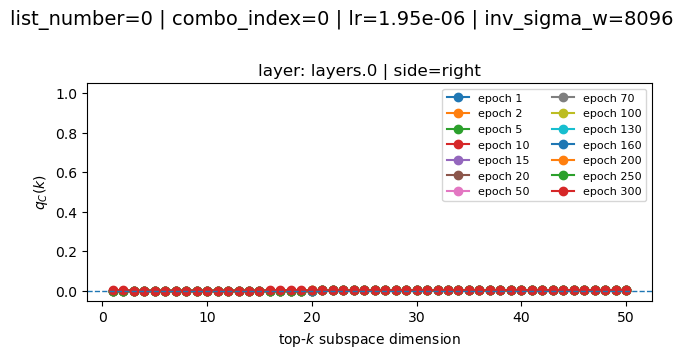

In [8]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    list_instead_of_grid=True,
    list_number=0,
    layers=["layers.0"],
    side="right",
    max_k=50,
)

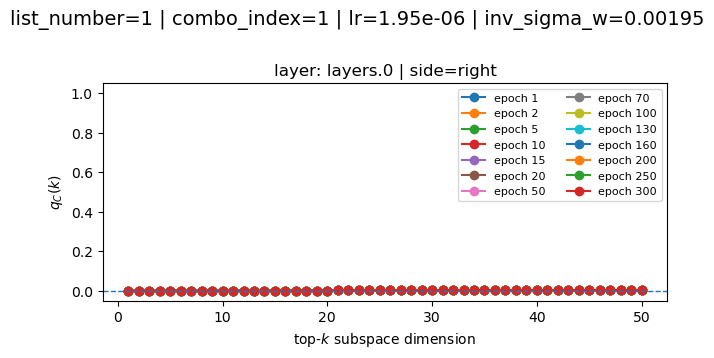

In [9]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    list_instead_of_grid=True,
    list_number=1,
    layers=["layers.0"],
    side="right",
    max_k=50,
)

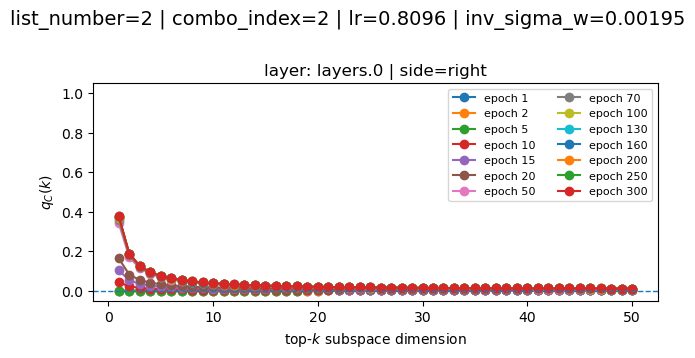

In [10]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    list_instead_of_grid=True,
    list_number=2,
    layers=["layers.0"],
    side="right",
    max_k=50,
)

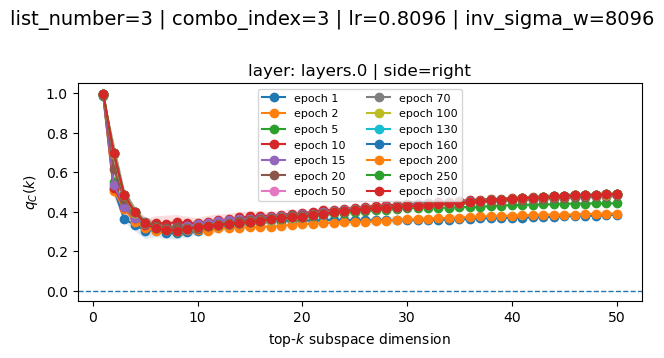

In [11]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    list_instead_of_grid=True,
    list_number=3,
    layers=["layers.0"],
    side="right",
    max_k=50,
)

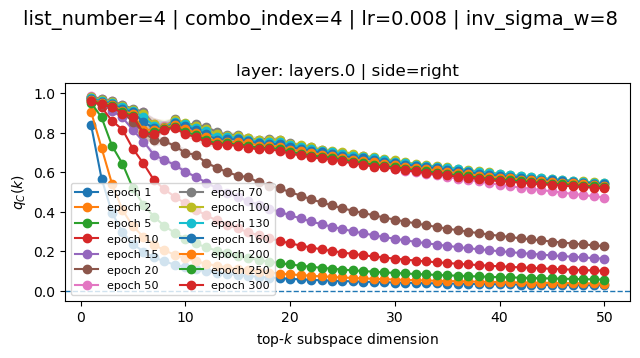

In [63]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v4",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    list_instead_of_grid=True,
    list_number=4,
    layers=["layers.0"],
    side="right",
    max_k=50,
)

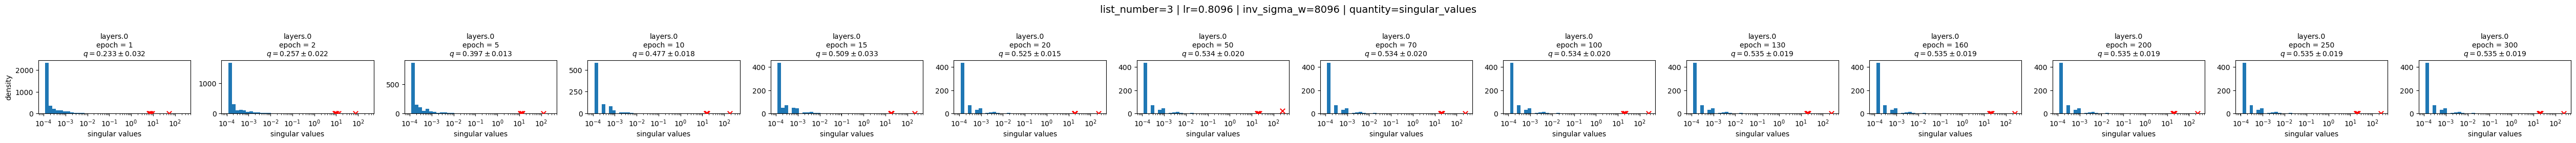

In [58]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=3,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

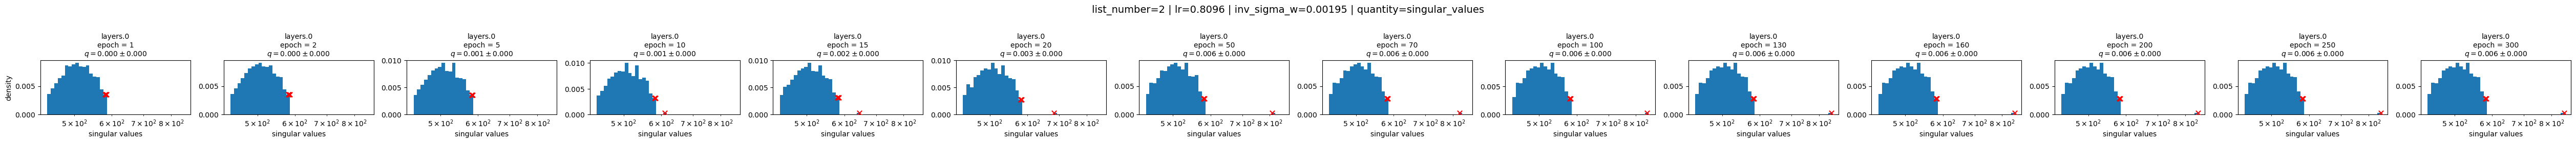

In [8]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=2,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

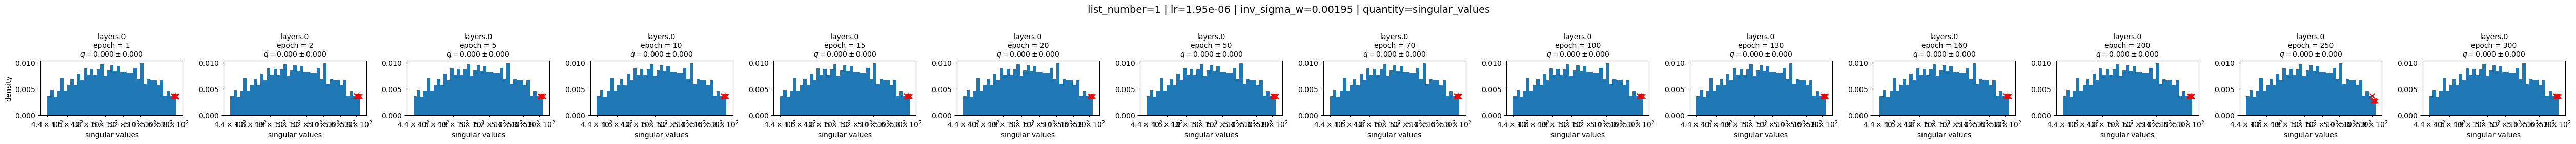

In [9]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=1,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

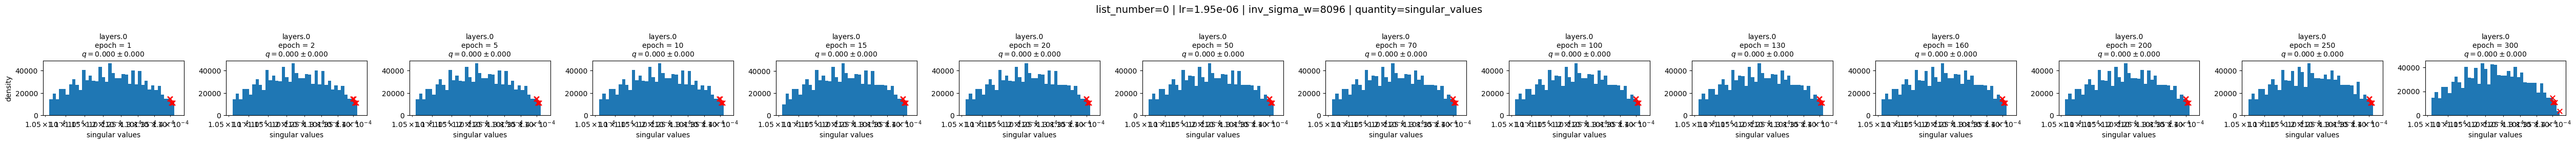

In [10]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

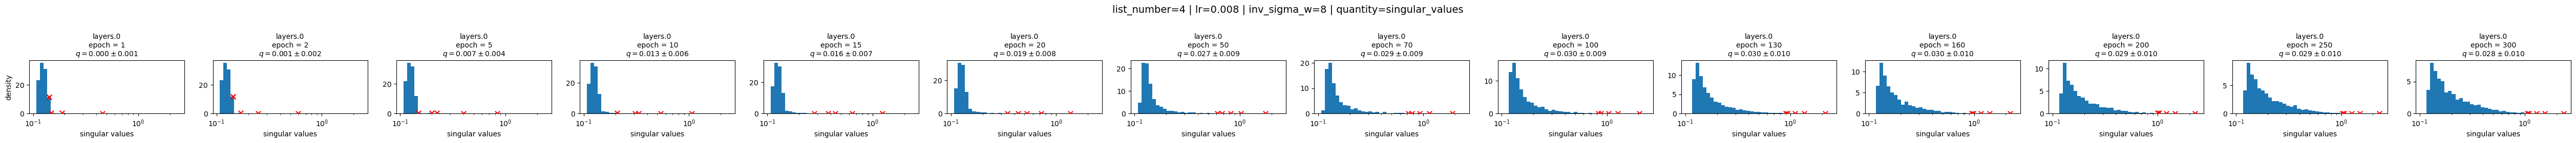

In [59]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

### 1 layer - tanh

In [4]:
results_dir = "data/experiment_2/exp2_SVD_dnn_SMALL_sgd_tanh_v1"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


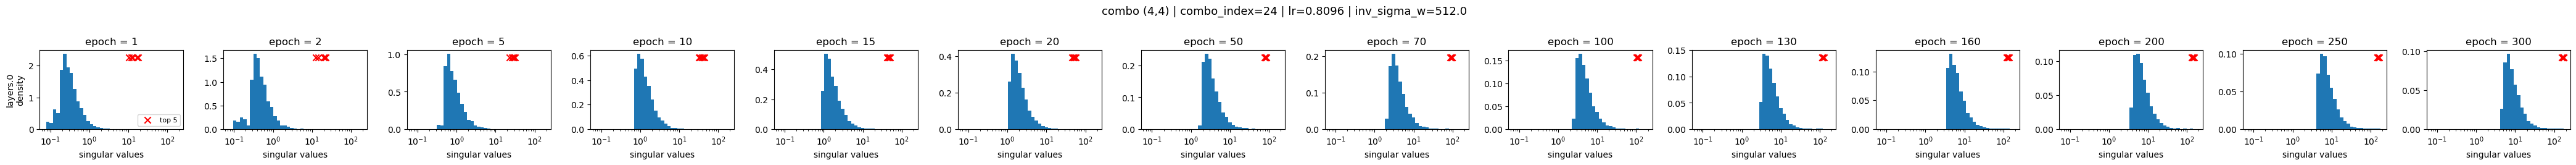

In [5]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

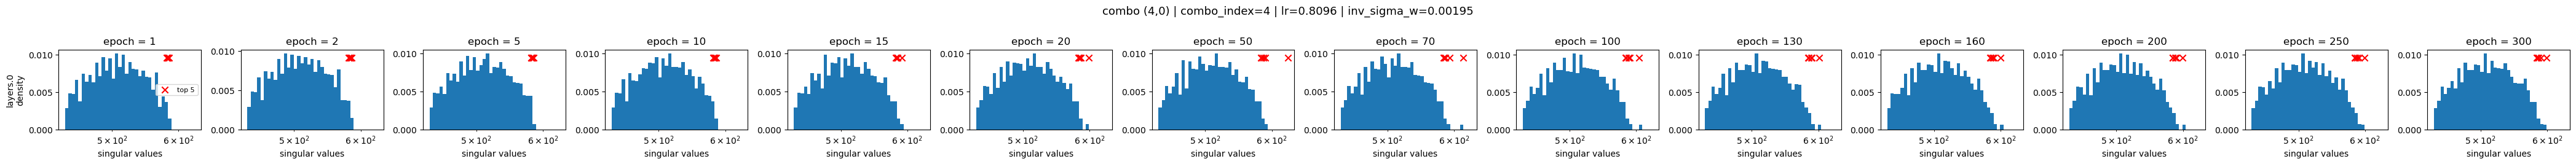

In [7]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

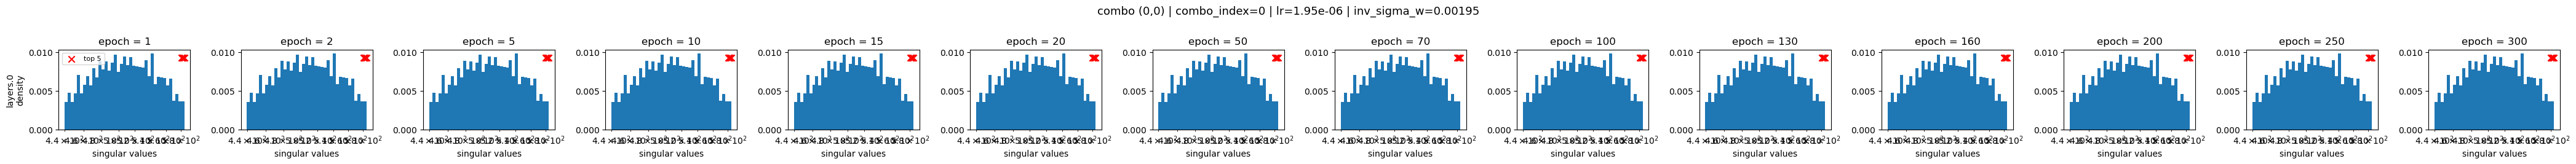

In [8]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

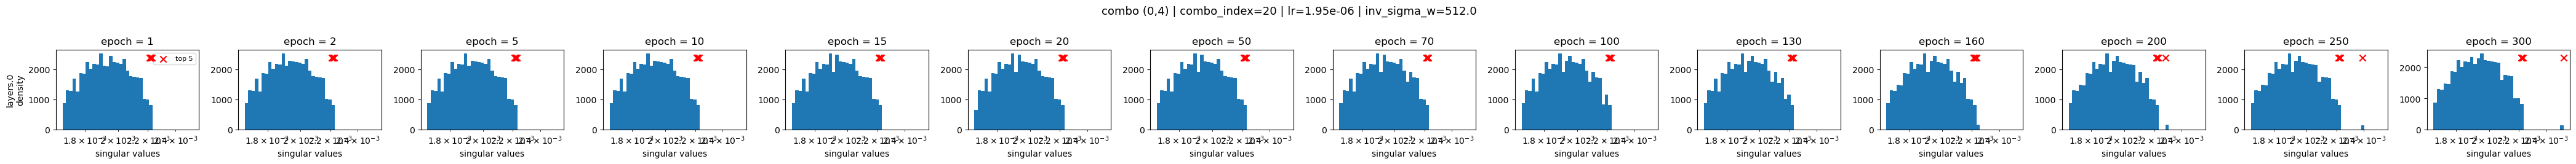

In [9]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

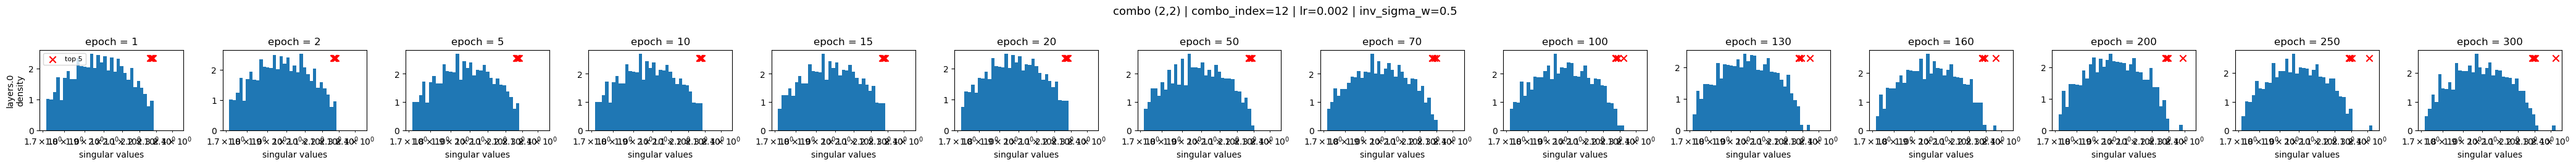

In [10]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

### 3 layers - relu

In [64]:
results_dir = "data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 5 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


In [65]:
res = compute_weight_overlaps_across_seeds(
    "exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    data_root="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2",
    checkpoint_filename="weight_checkpoints.pt",
)

summary = res["summary"]
pairs = res["pairs"]

summary.shape, pairs.shape

((280,), (1680,))

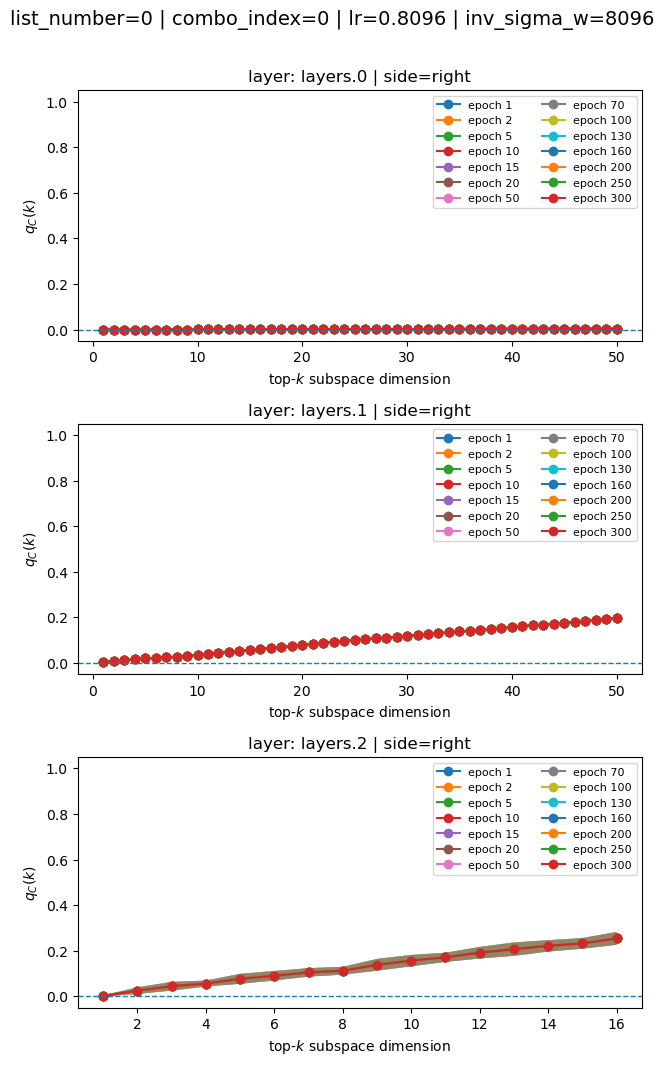

In [66]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json",
    list_instead_of_grid=True,
    list_number=0,
    layers=["layers.0", "layers.1", "layers.2"],
    side="right",
    max_k=50,
)

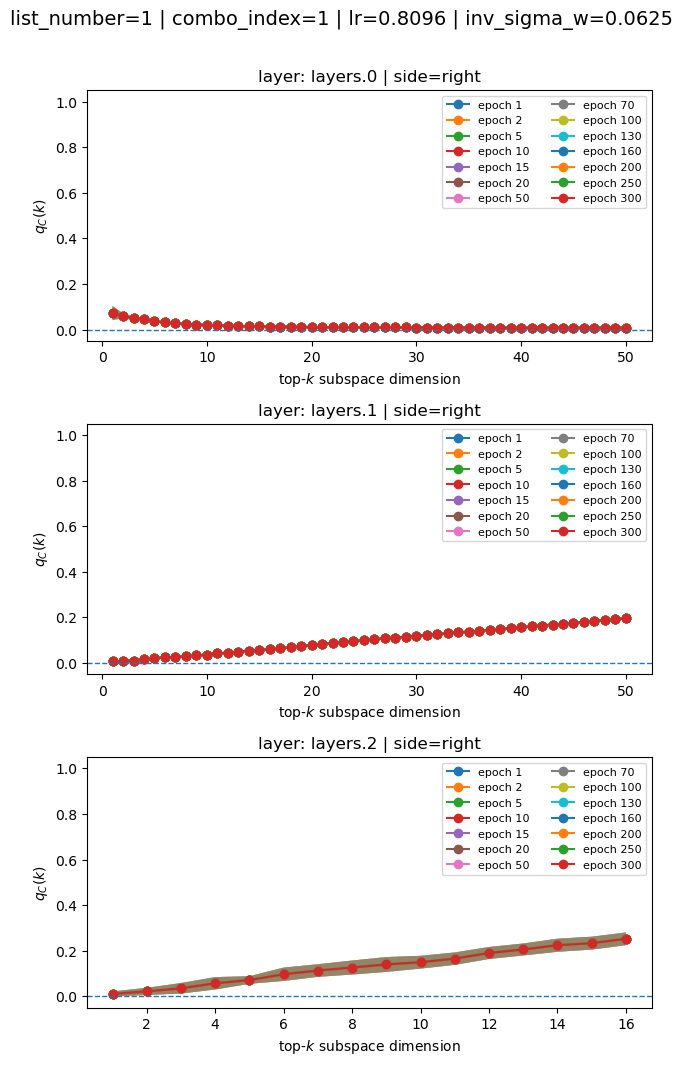

In [67]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json",
    list_instead_of_grid=True,
    list_number=1,
    layers=["layers.0", "layers.1", "layers.2"],
    side="right",
    max_k=50,
)

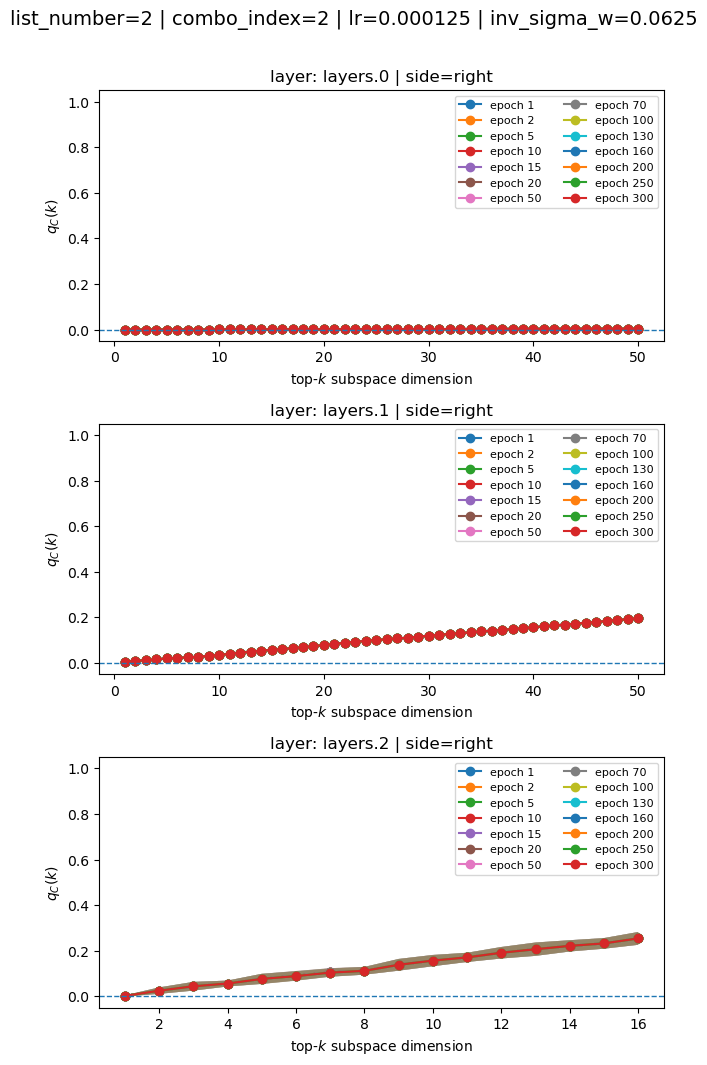

In [68]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json",
    list_instead_of_grid=True,
    list_number=2,
    layers=["layers.0", "layers.1", "layers.2"],
    side="right",
    max_k=50,
)

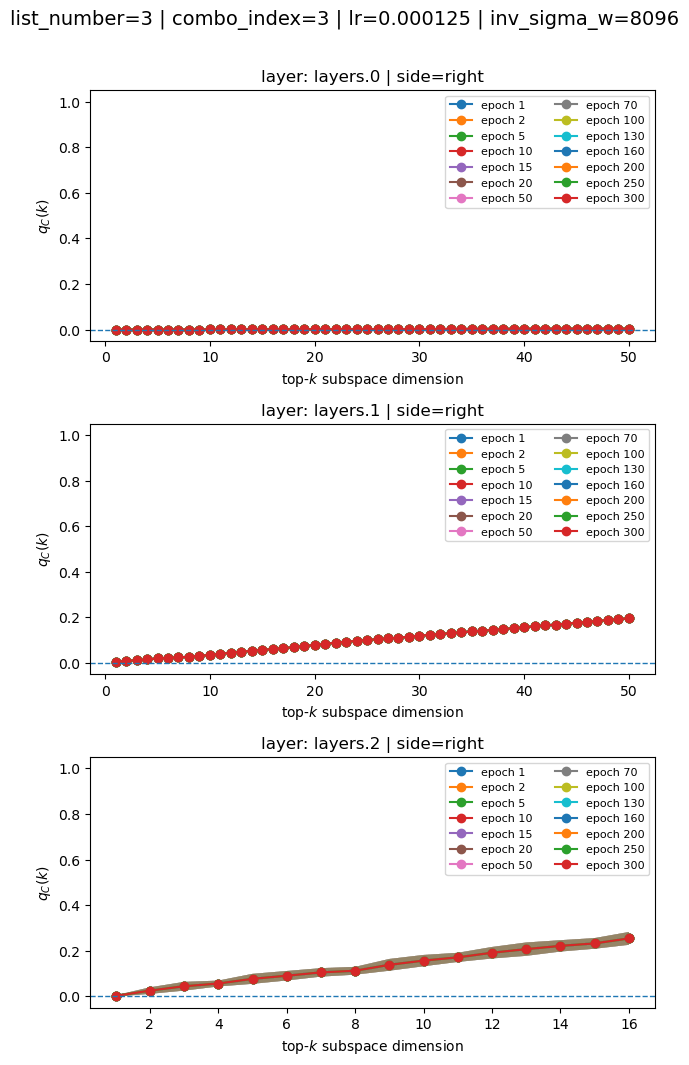

In [69]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json",
    list_instead_of_grid=True,
    list_number=3,
    layers=["layers.0", "layers.1", "layers.2"],
    side="right",
    max_k=50,
)

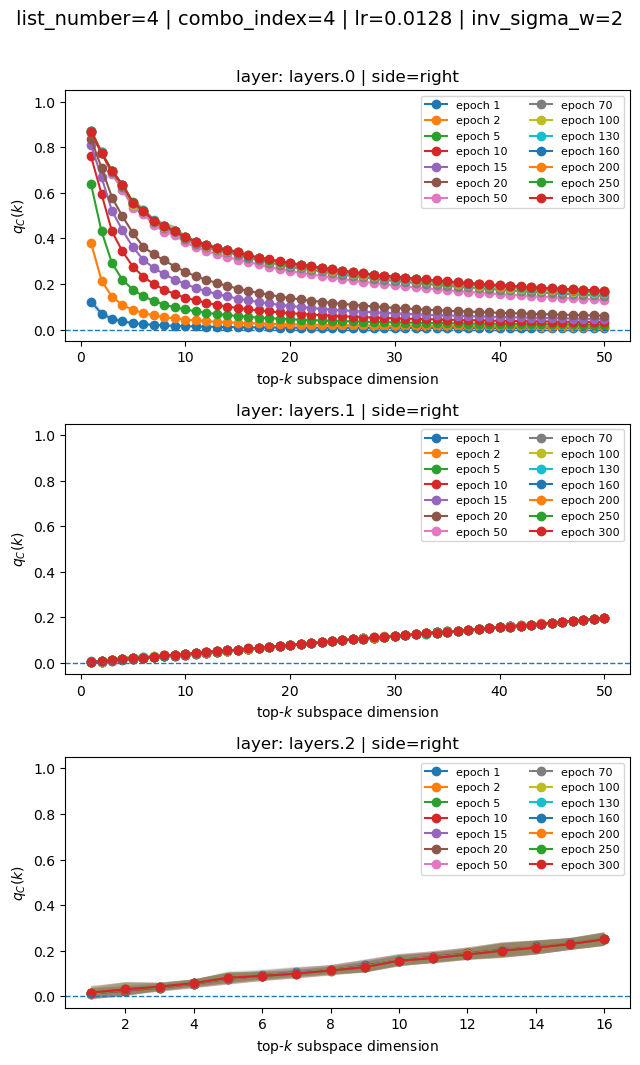

In [70]:
fig, axes, qC_res = plot_qC_subspace_overlap_vs_k(
    results_dir="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v6",
    config_path="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json",
    list_instead_of_grid=True,
    list_number=4,
    layers=["layers.0", "layers.1", "layers.2"],
    side="right",
    max_k=50,
)

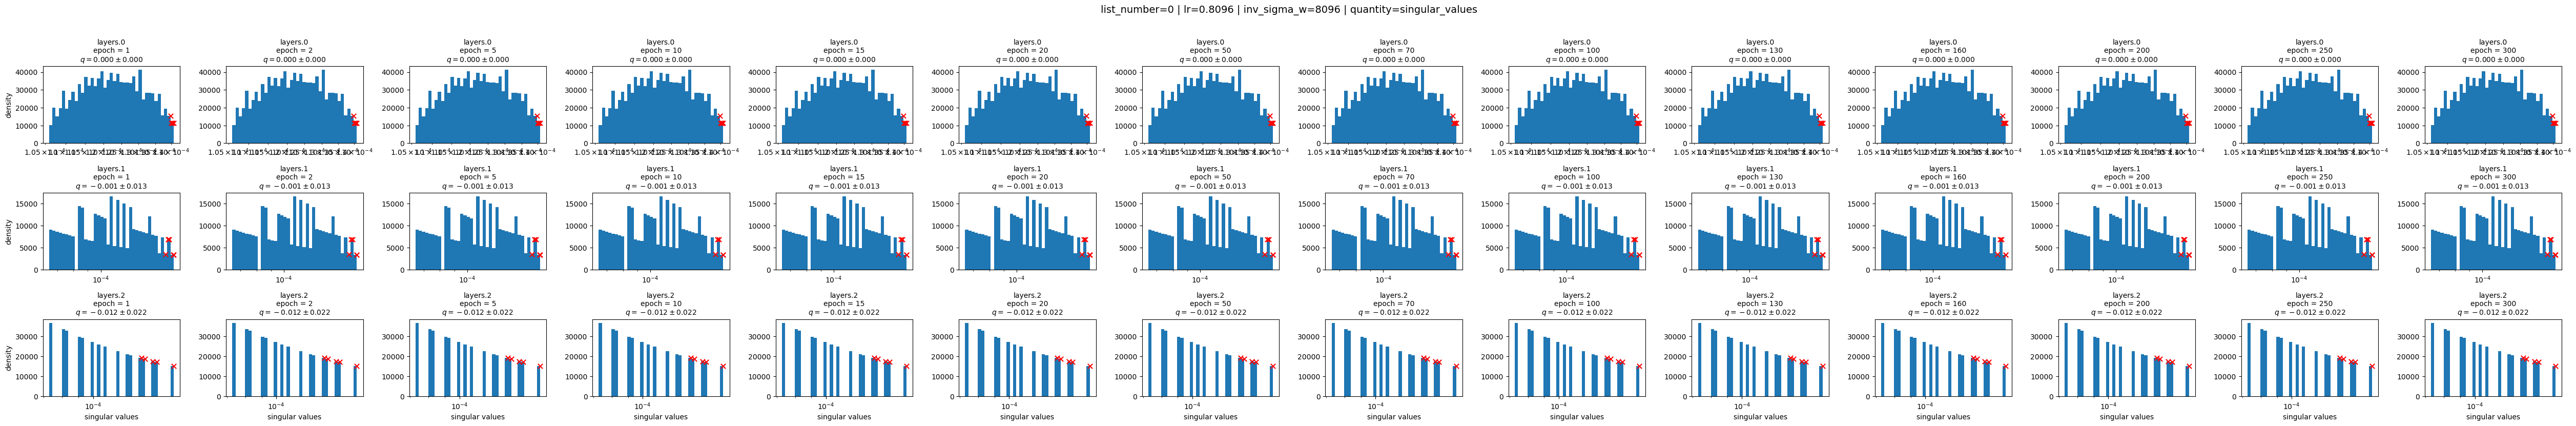

In [71]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=0,
    layers=["layers.0", "layers.1", "layers.2"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

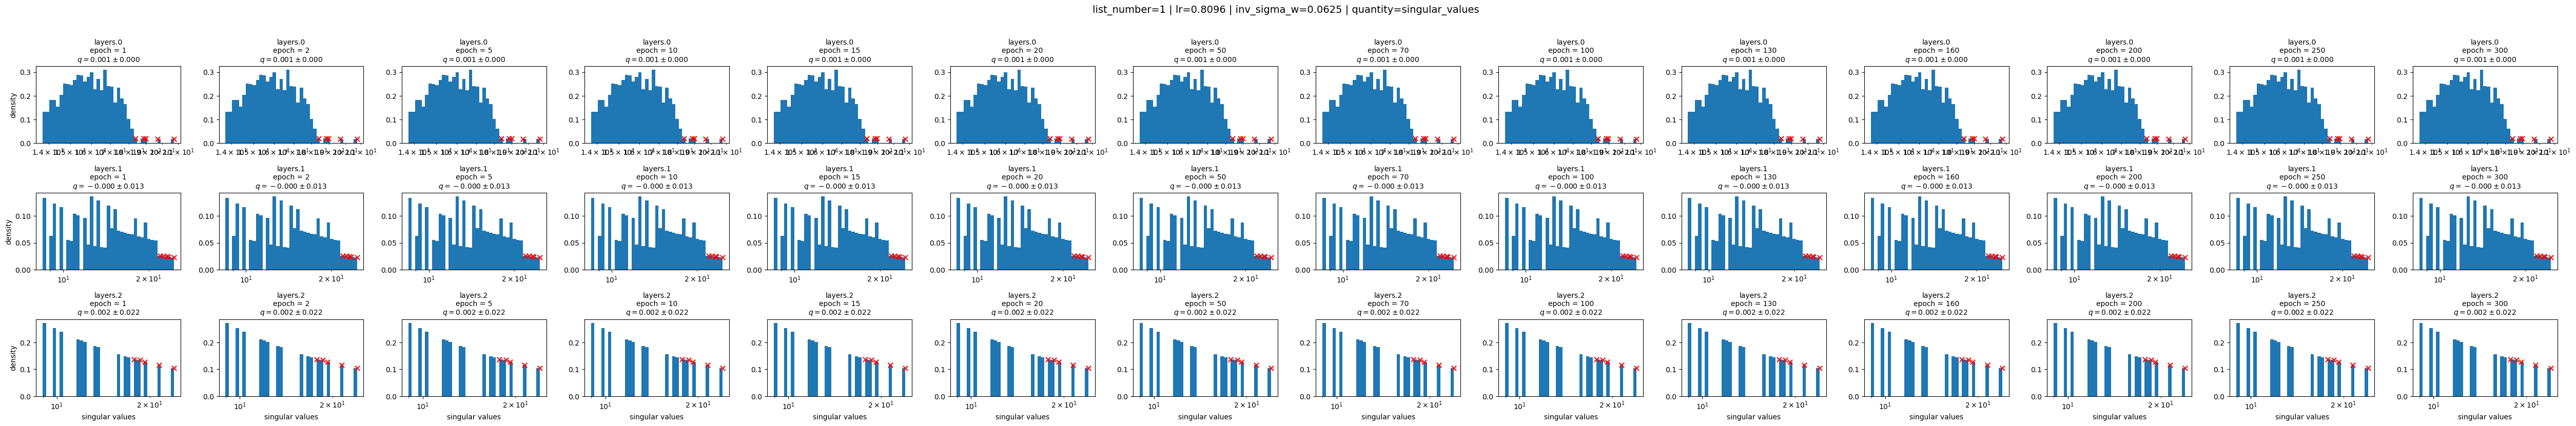

In [72]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=1,
    layers=["layers.0", "layers.1", "layers.2"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

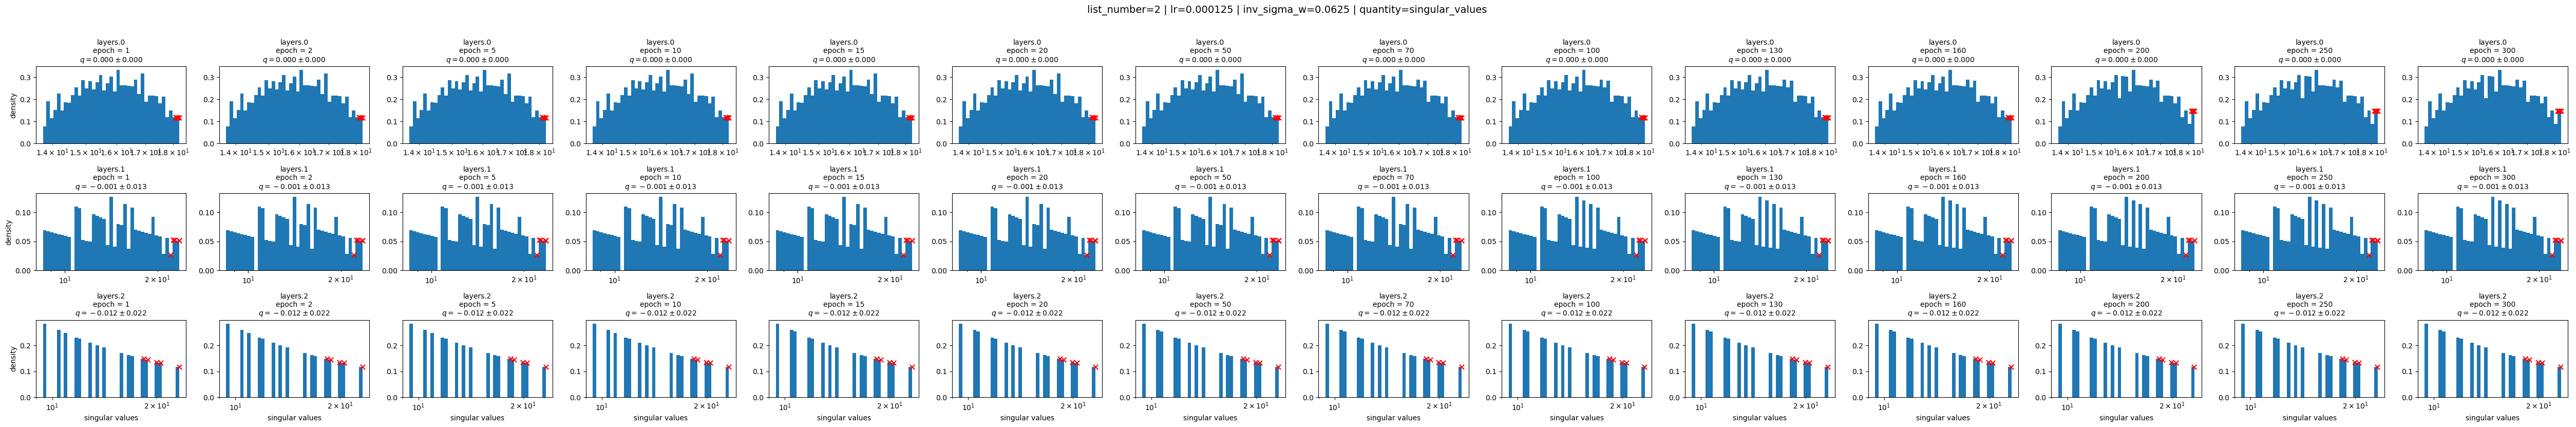

In [73]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=2,
    layers=["layers.0", "layers.1", "layers.2"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

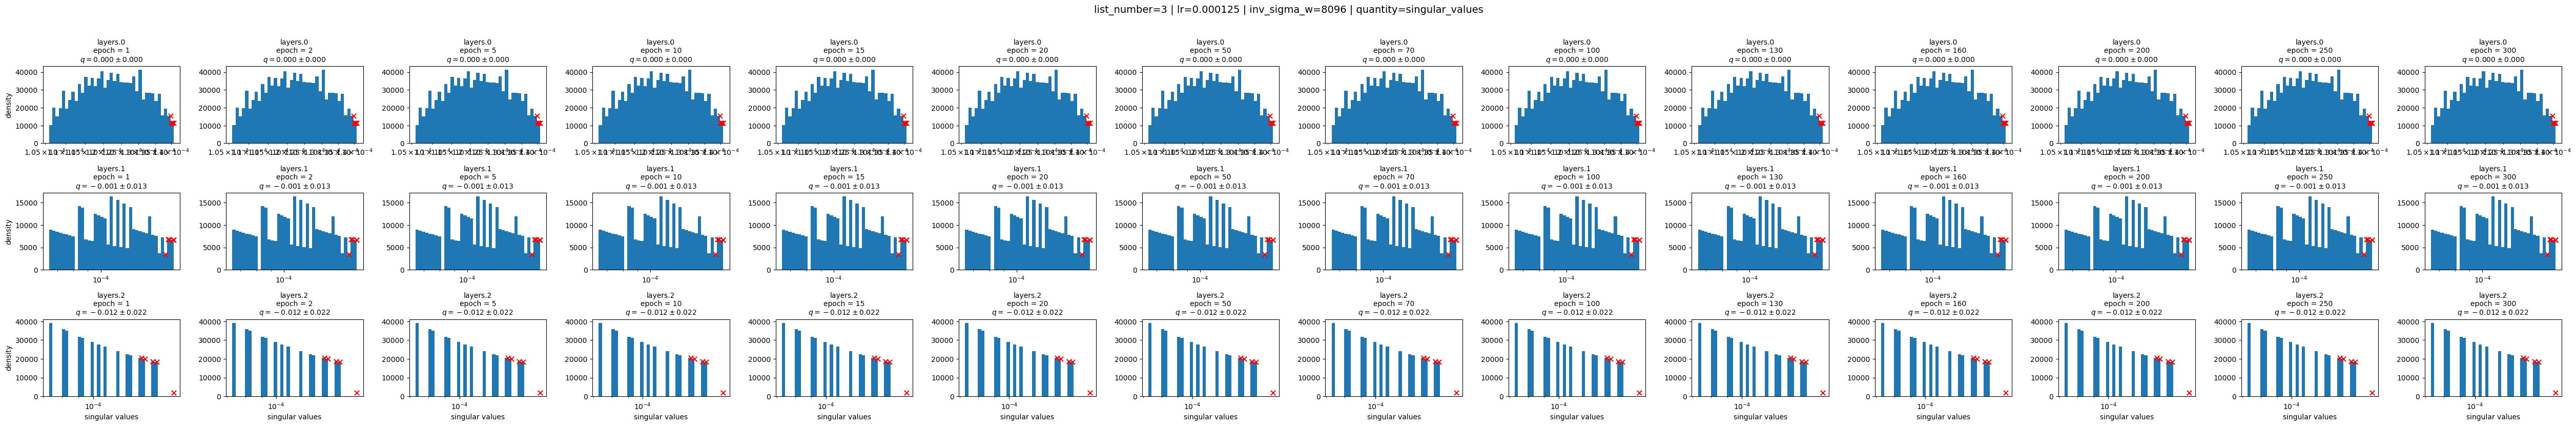

In [74]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=3,
    layers=["layers.0", "layers.1", "layers.2"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

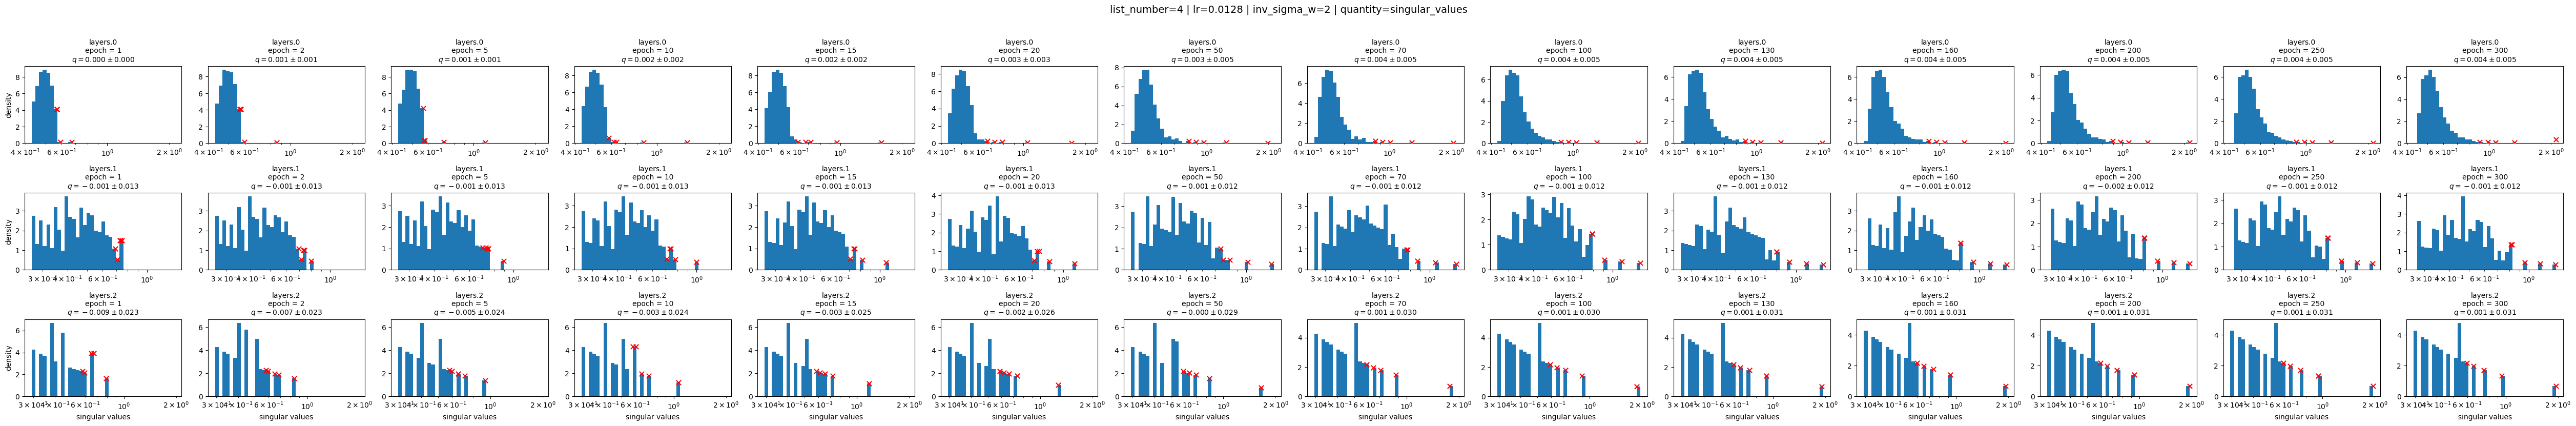

In [75]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    list_instead_of_grid=True,
    list_number=4,
    layers=["layers.0", "layers.1", "layers.2"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
    q_a=summary,   # this is res["summary"] from the overlap computation
)

### 3 layer - tanh

In [11]:
results_dir = "data/experiment_2/exp2_SVD_dnn_BIG_sgd_tanh_v1"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram_BIG.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


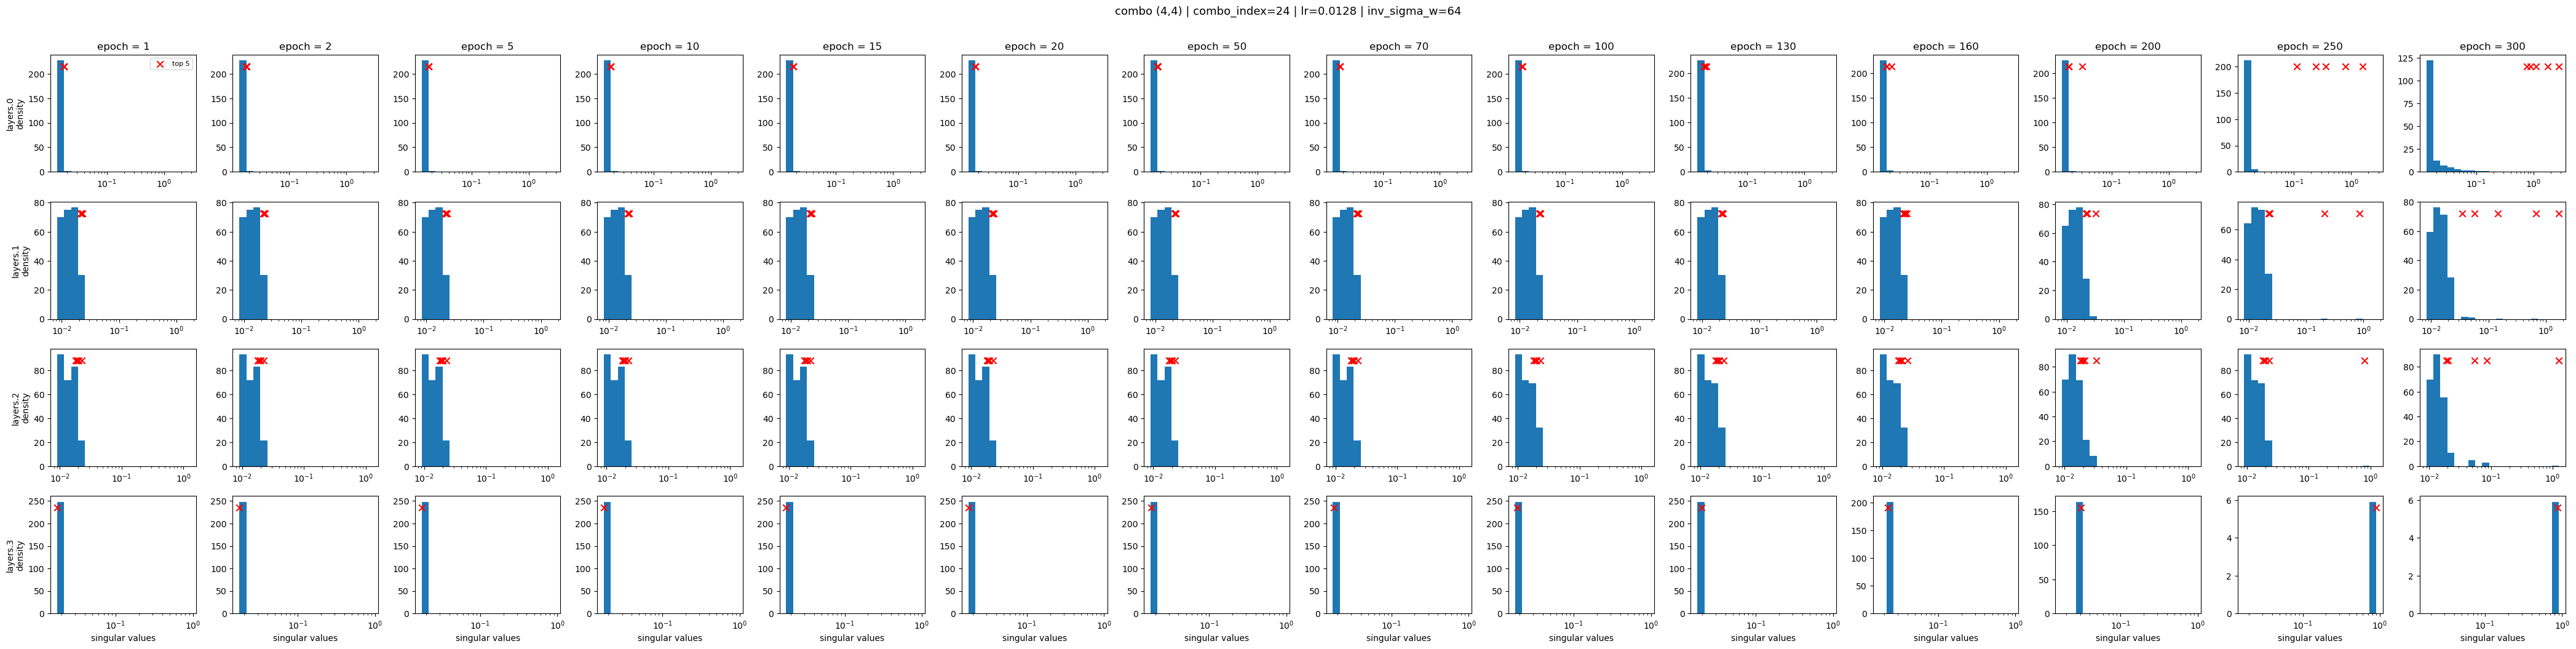

In [12]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

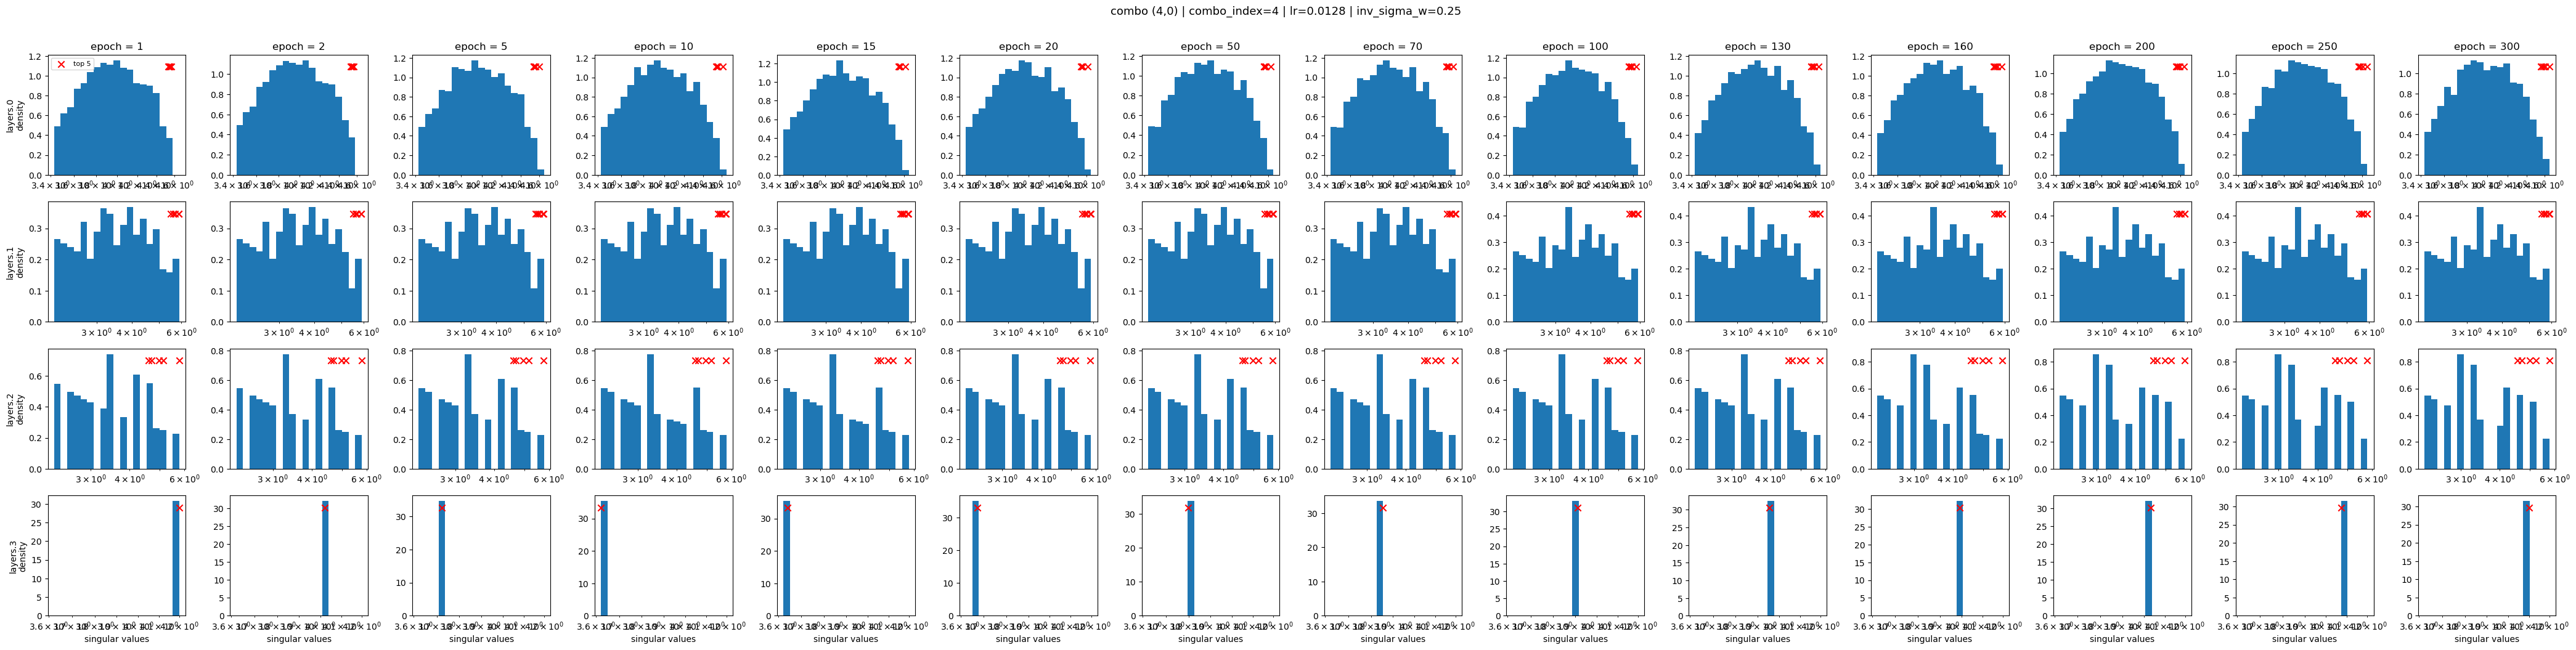

In [13]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

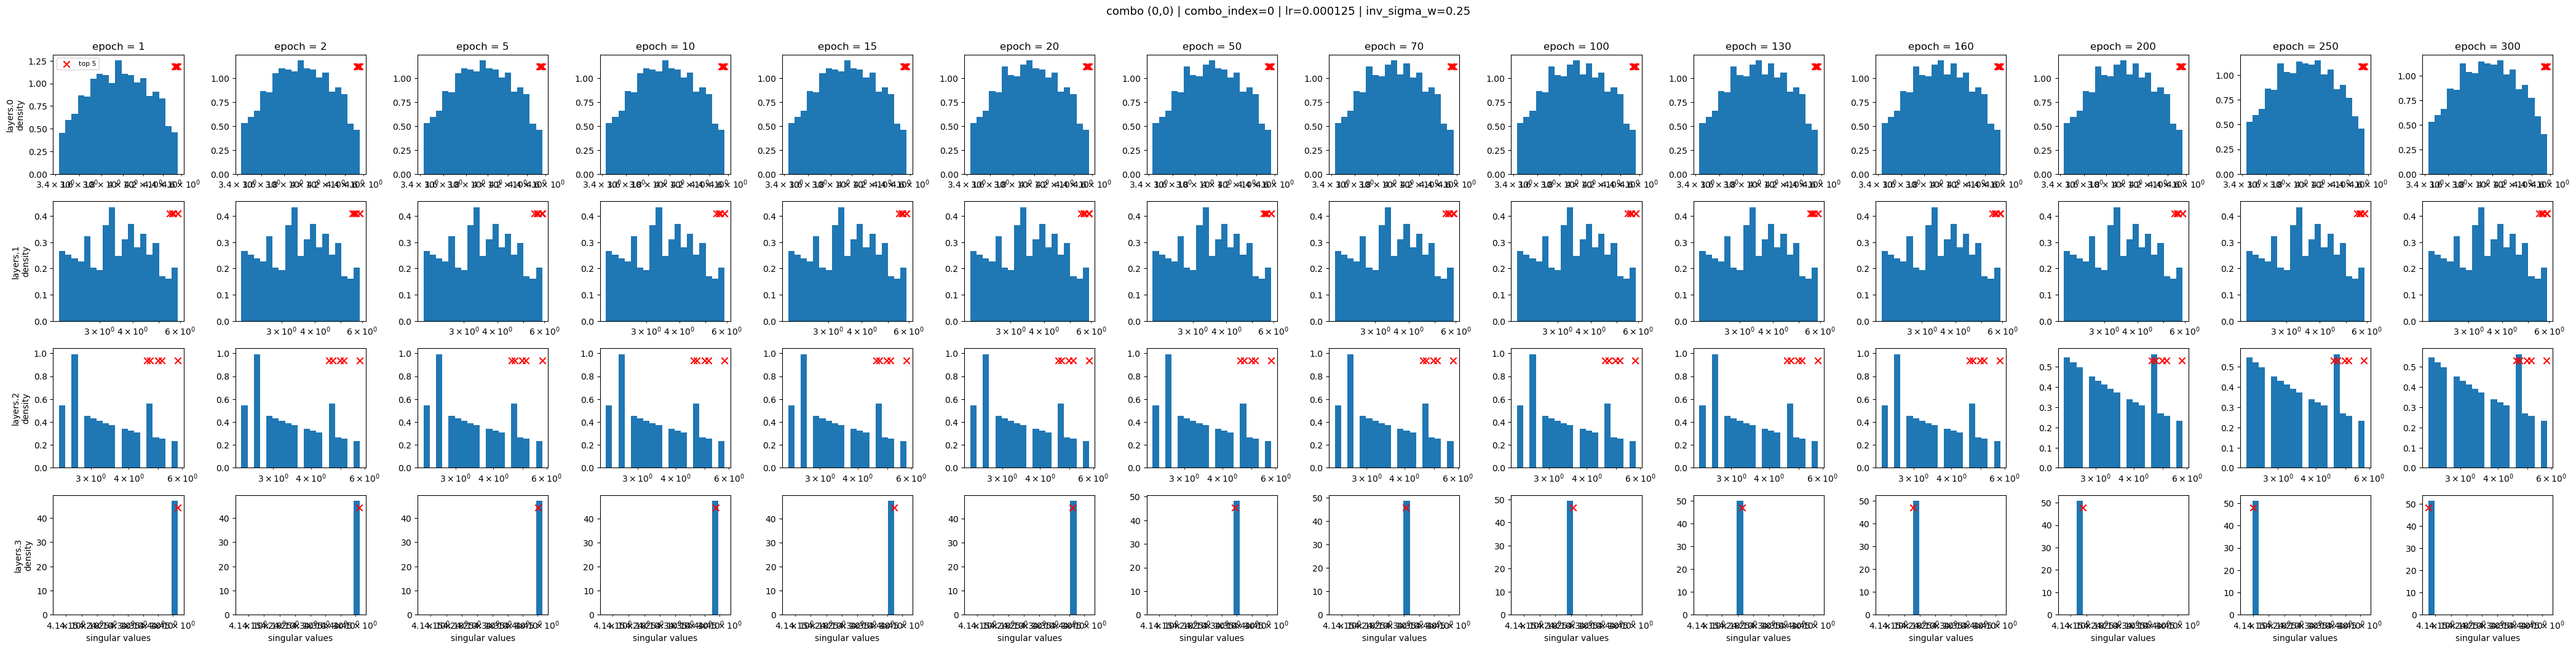

In [14]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

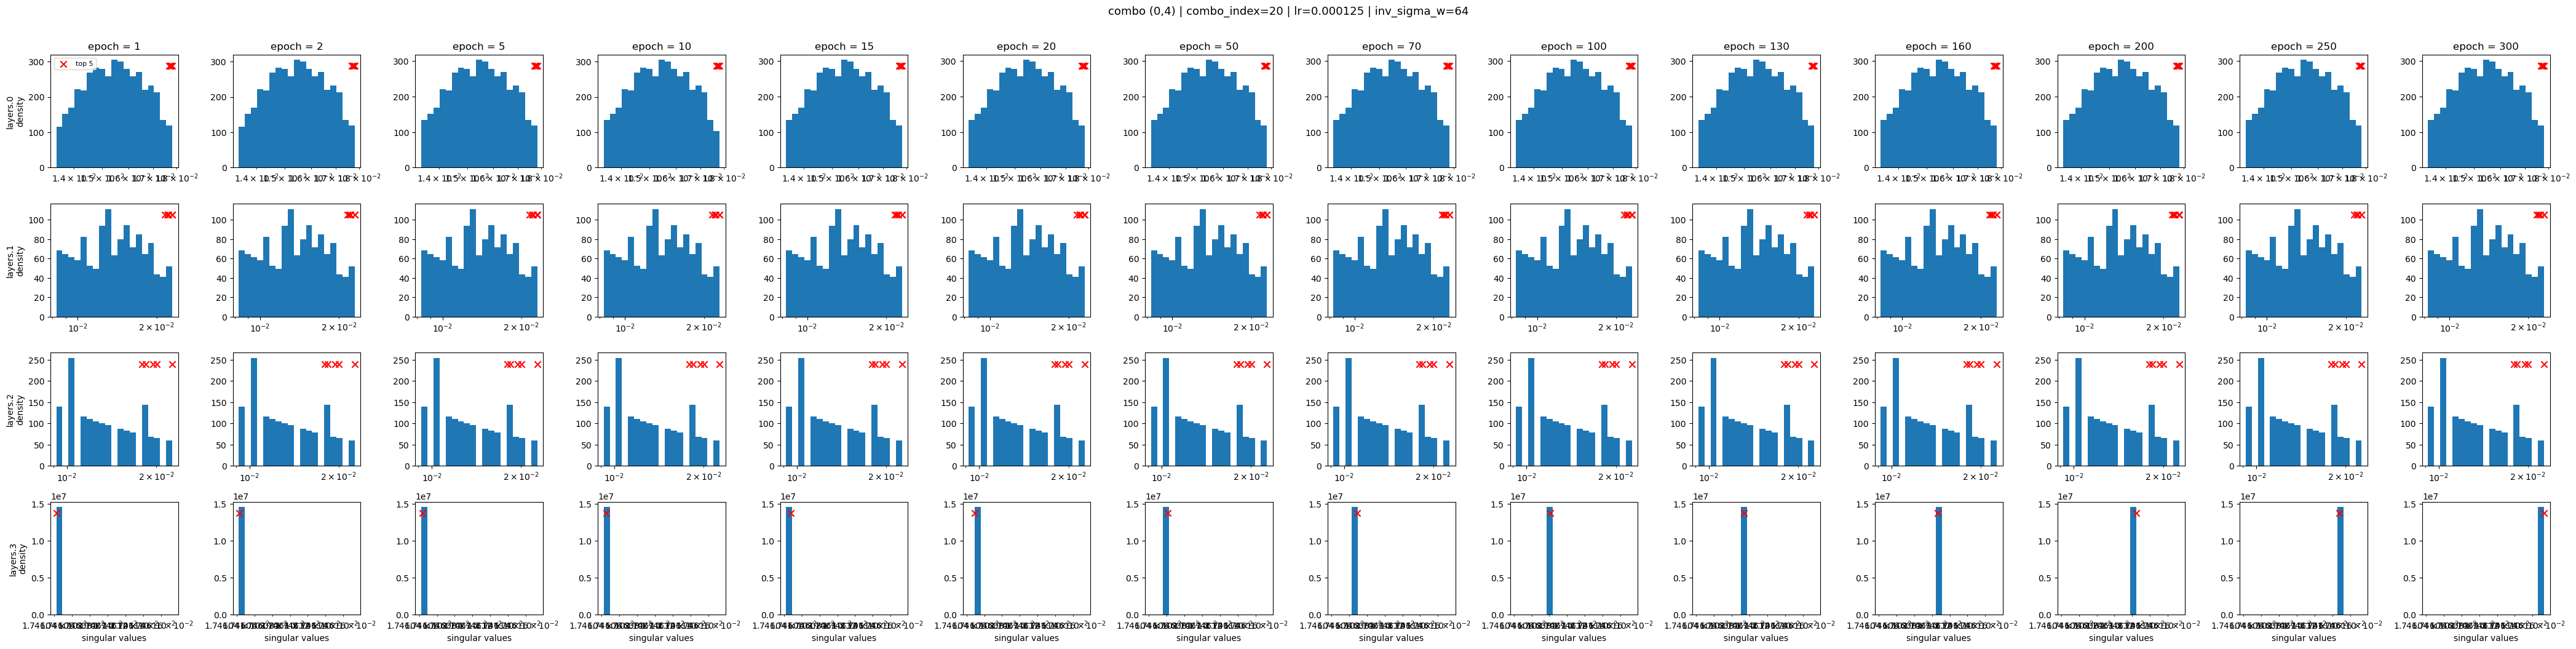

In [15]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

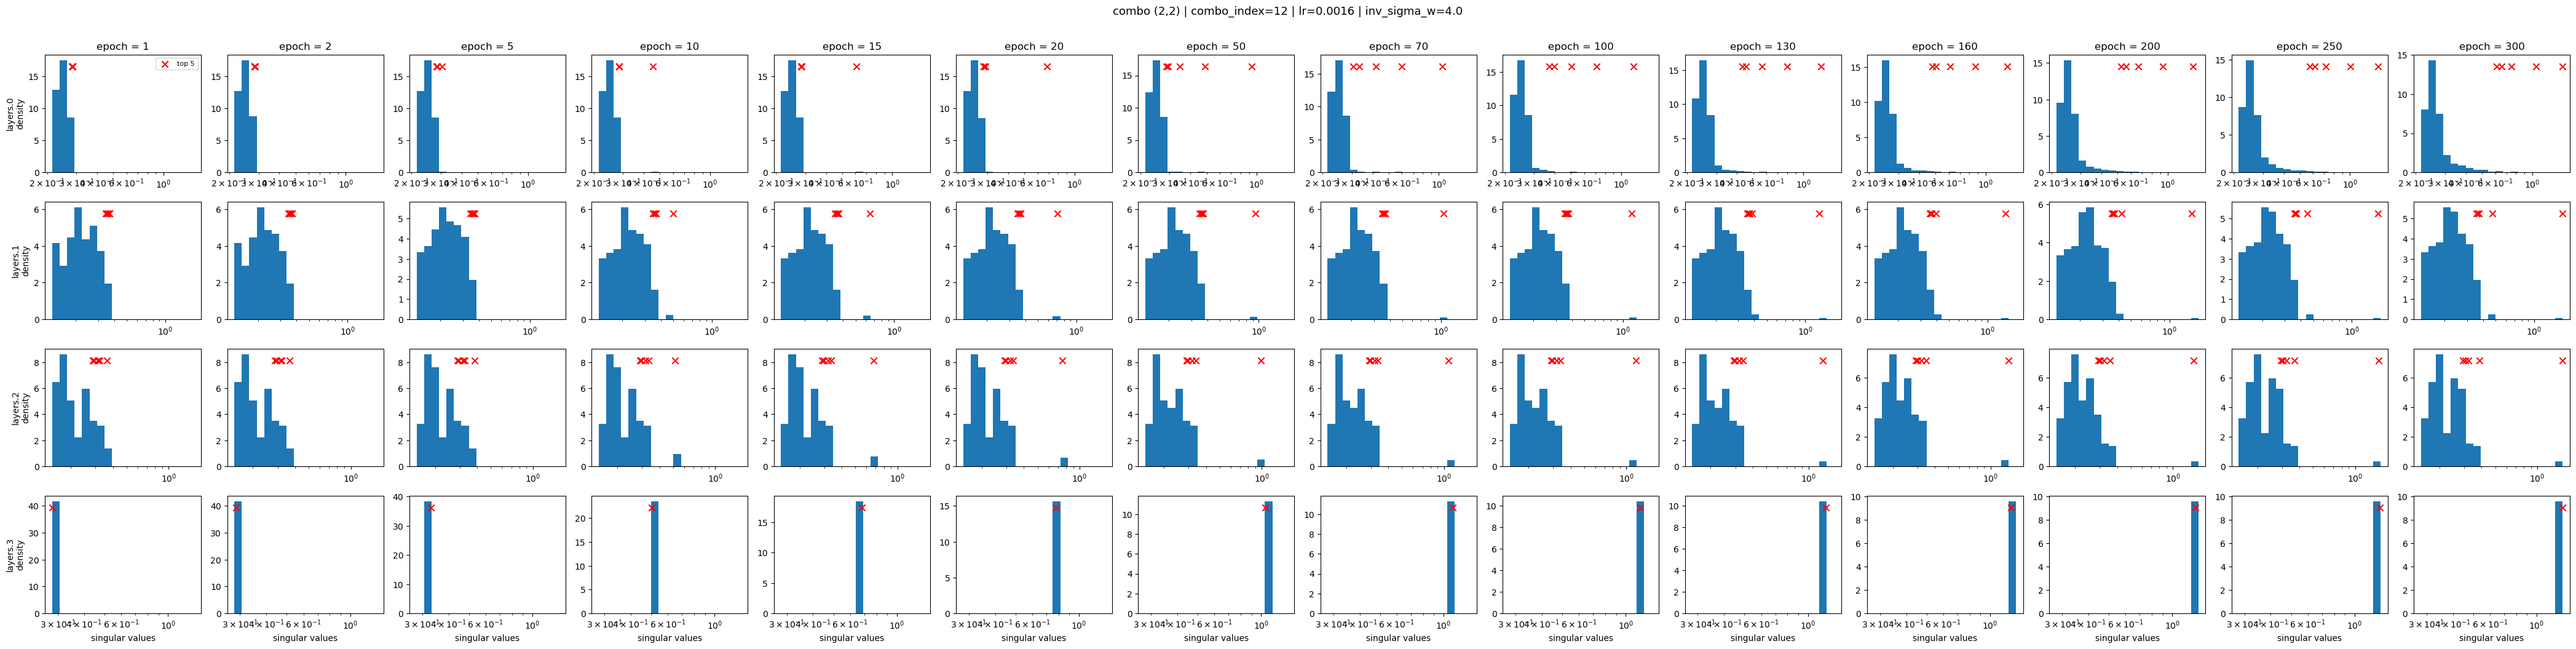

In [16]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

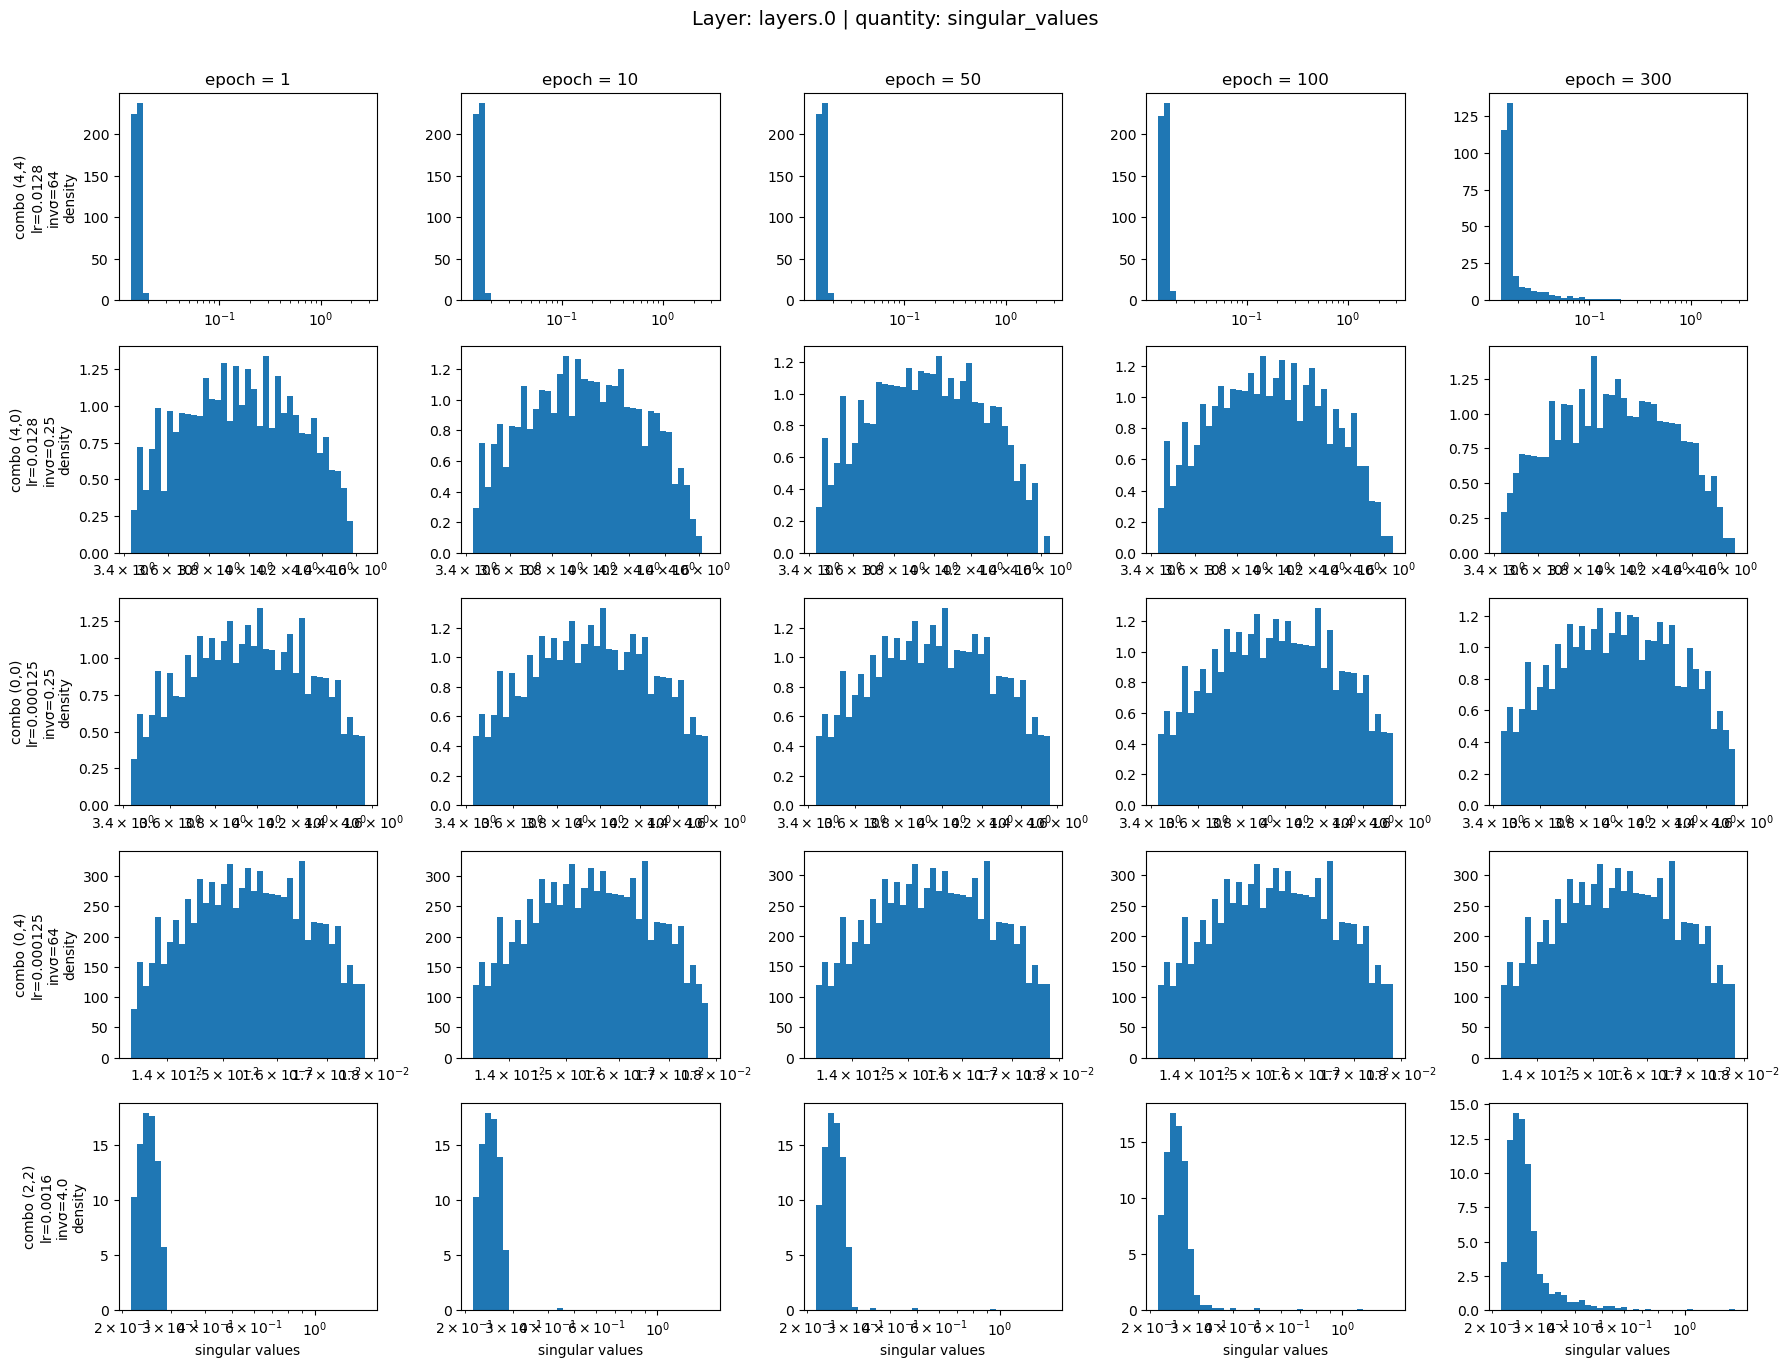

In [17]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.0",
    value_key="singular_values",
)

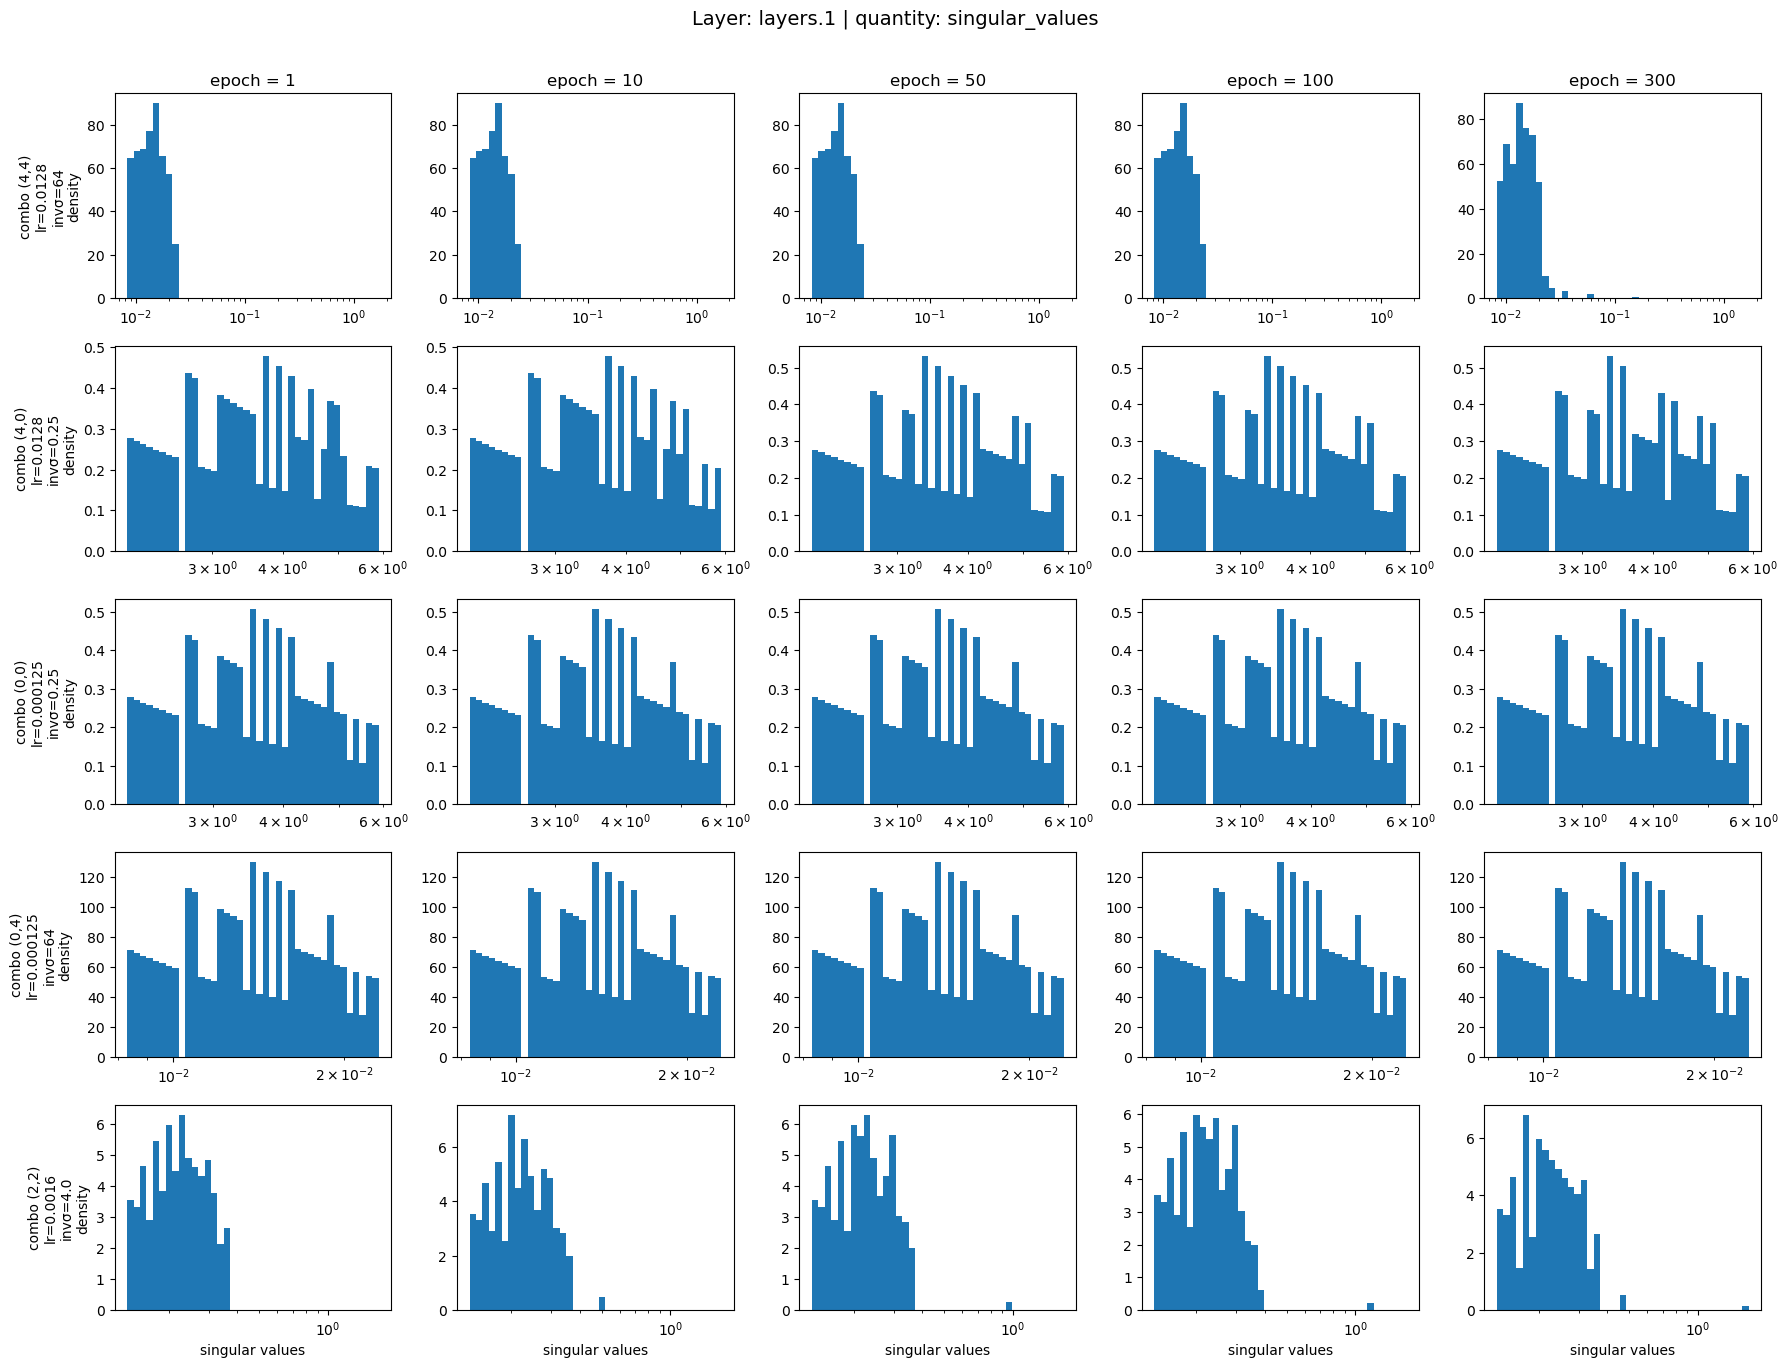

In [18]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.1",
    value_key="singular_values",
)

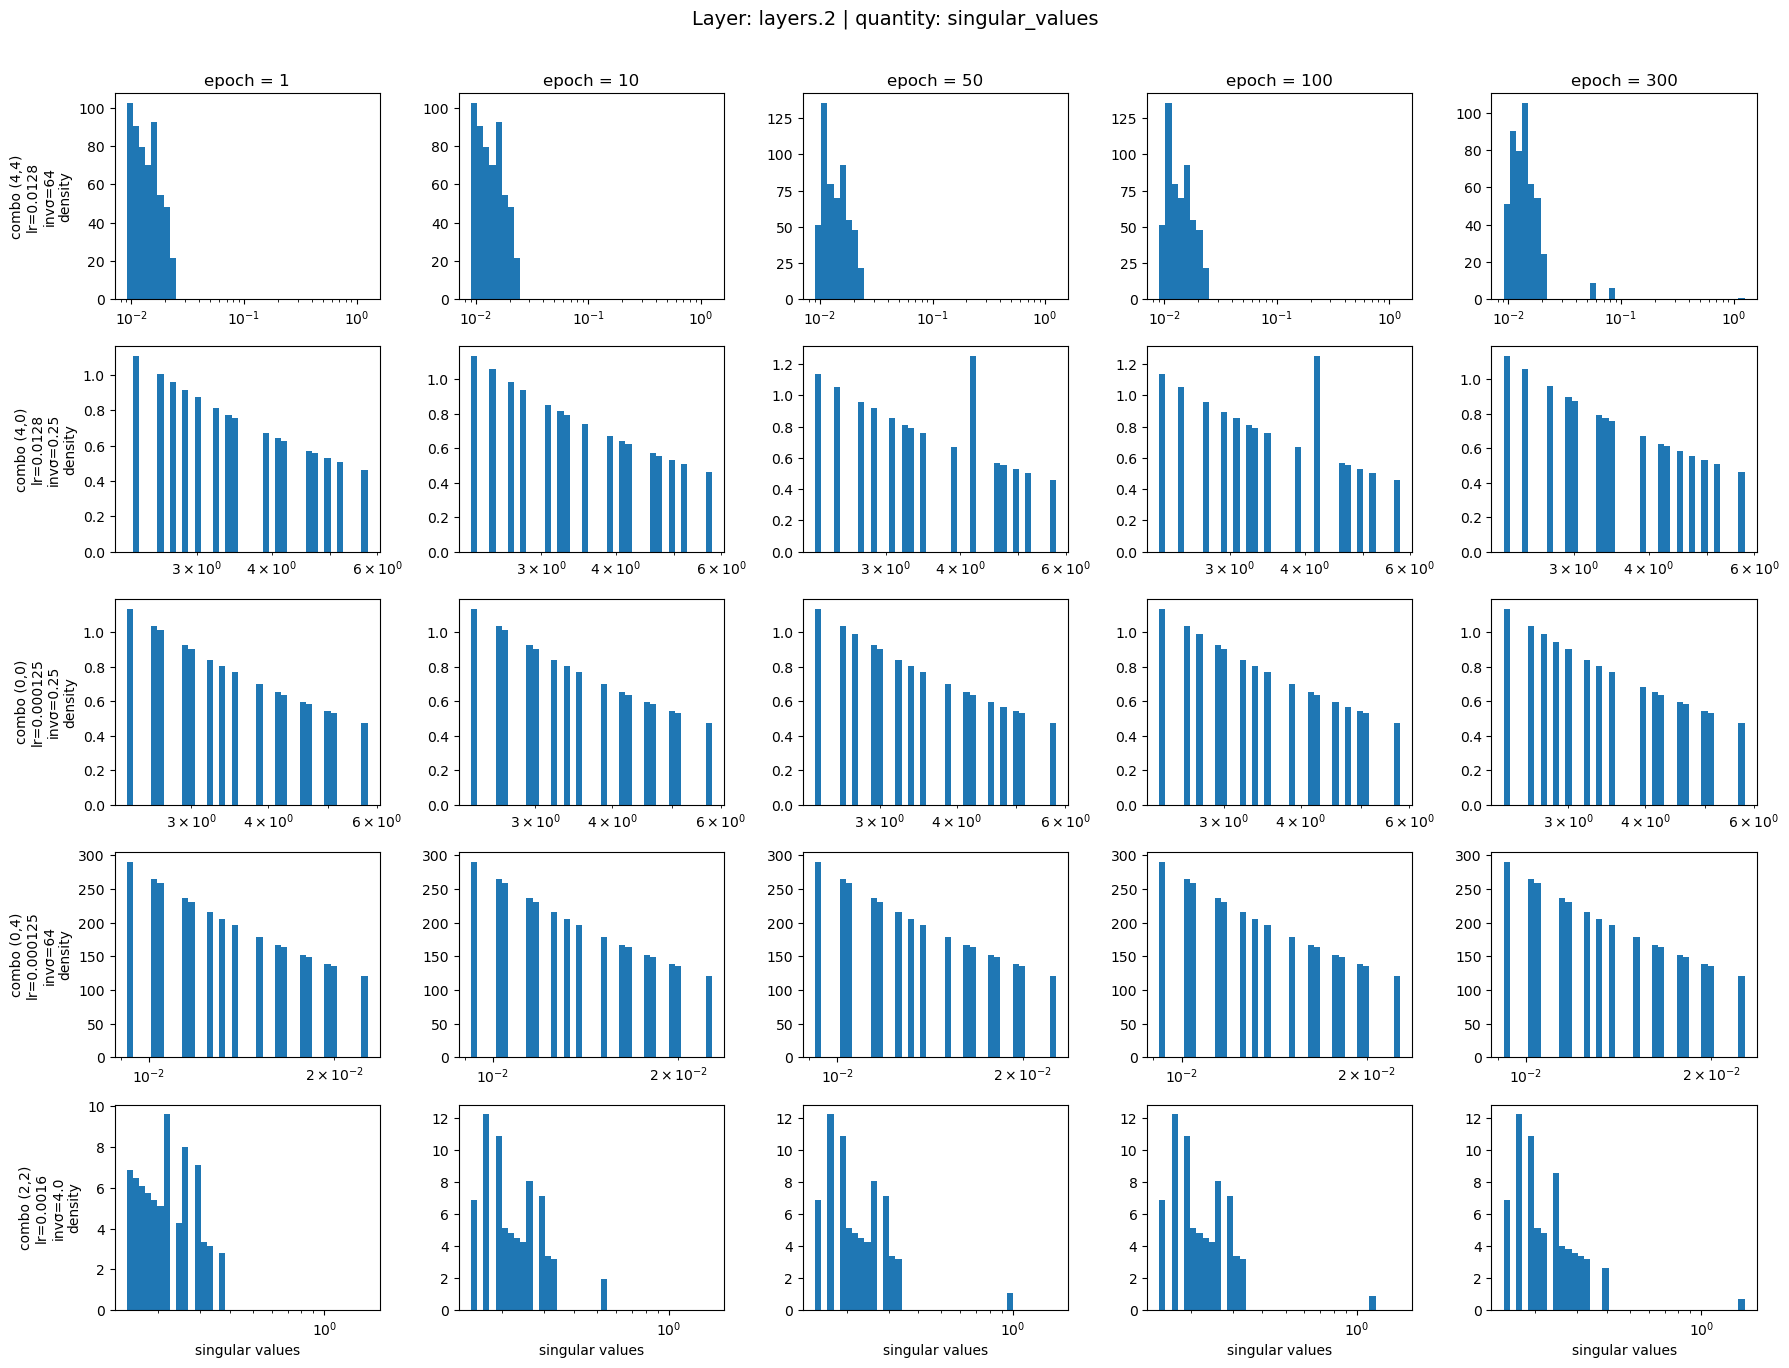

In [19]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.2",
    value_key="singular_values",
)